In [1]:
import sys
sys.path.append('../scripts')  # Adjust path as needed
from module import (
    count_usage_cases,
    create_degree_lists,
    count_cluster_wise,
    pre_vec,
    nordept,
    deptwisecount,
    normalized_dept_cluster,
    create_vector,
    create_vector2,
    clear_vec,
    culster_wise_val,
    create_con_table,
    chi_square_test,
    residuals_cal,
    create_group,
    normality_test,
    agostino_pearson_test,
    kruskal_wallis_test
)
from plots import ( grouped_bar_graph_horizontal_color, stacked_bar_graph, grouped_bar_graph_horizontal_color_white, boxplot,
    kde_plot,
    heatmap_plot
)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches  # For patterns

In [3]:
file_path = '/Users/jesanahammed/Desktop/dataset/GenAI.csv'
df = pd.read_csv(file_path, encoding='latin1')
df.columns = df.columns.str.replace(r'[^\x00-\x7F]+', '', regex=True)  # Remove non-ASCII characters
df.columns = df.columns.str.strip()  # Strip any leading/trailing spaces

In [4]:
print(len(df['Response ID']))

862


In [5]:
clear_vec()

In [6]:
c1, c2, c3, c4, c5 = create_vector(df, 44)

[0, 145, 117, 53, 65, 21]
[145]


In [7]:
c1, c2, c3, c4, c5 = create_vector(df, 40)

[0, 129, 110, 45, 59, 15]
[145, 129]


In [8]:
c1, c2, c3, c4, c5 = create_vector(df, 43)

[0, 117, 103, 42, 61, 14]
[145, 129, 117]


In [9]:
c1, c2, c3, c4, c5 = create_vector(df, 41)

[0, 114, 106, 39, 58, 18]
[145, 129, 117, 114]


In [10]:
c1, c2, c3, c4, c5 = create_vector(df, 46)

[0, 117, 80, 51, 55, 14]
[145, 129, 117, 114, 117]


In [11]:
c1, c2, c3, c4, c5 = create_vector(df, 47)

[0, 100, 101, 39, 50, 18]
[145, 129, 117, 114, 117, 100]


In [12]:
c1, c2, c3, c4, c5 = create_vector(df, 45)

[0, 105, 92, 45, 46, 18]
[145, 129, 117, 114, 117, 100, 105]


In [13]:
c1, c2, c3, c4, c5 = create_vector(df, 42)

[0, 56, 59, 22, 29, 10]
[145, 129, 117, 114, 117, 100, 105, 56]


In [14]:
c1, c2, c3, c4, c5 = create_vector(df, 48)

[0, 39, 43, 23, 22, 7]
[145, 129, 117, 114, 117, 100, 105, 56, 39]


In [20]:
def aggregated_count(c1, c2, c3, c4, c5):
    temp = []
    for i in range(len(c1)):
        temp.append(c1[i] + c2[i] + c3[i] + c4[i] + c5[i])
    return temp

In [23]:
c1_copy = c1
c2_copy = c2
c3_copy = c3
c4_copy = c4
c5_copy = c5


print(c1_copy)
print(c2_copy)
print(c3_copy)
print(c4_copy)
print(c5_copy)

agg = aggregated_count(c1, c2, c3, c4, c5)
print(agg)

for i in range (len(agg)):
    agg[i] = round((agg[i]/(234+182+86+115+28)*100), 1)
print(agg)

[145, 129, 117, 114, 117, 100, 105, 56, 39]
[117, 110, 103, 106, 80, 101, 92, 59, 43]
[53, 45, 42, 39, 51, 39, 45, 22, 23]
[65, 59, 61, 58, 55, 50, 46, 29, 22]
[21, 15, 14, 18, 14, 18, 18, 10, 7]
[401, 358, 337, 335, 317, 308, 306, 176, 134]
[62.2, 55.5, 52.2, 51.9, 49.1, 47.8, 47.4, 27.3, 20.8]


In [24]:
columns_to_check = [
    df.iloc[:, 40], df.iloc[:, 41], df.iloc[:, 42], df.iloc[:, 43], df.iloc[:, 44],
    df.iloc[:, 45], df.iloc[:, 46], df.iloc[:, 47], df.iloc[:, 48], df.iloc[:, 49],
    df.iloc[:, 50], df.iloc[:, 51], df.iloc[:, 52], df.iloc[:, 53], df.iloc[:, 54],
    df.iloc[:, 55], df.iloc[:, 56], df.iloc[:, 57], df.iloc[:, 58]
]
c1 = normalized_dept_cluster(df, c1, columns_to_check, 1)
c2 = normalized_dept_cluster(df, c2, columns_to_check, 2)
c3 = normalized_dept_cluster(df, c3, columns_to_check, 3)
c4 = normalized_dept_cluster(df, c4, columns_to_check, 4)
c5 = normalized_dept_cluster(df, c5, columns_to_check, 5)

print(c1)
print(c2)
print(c3)
print(c4)
print(c5)


234
182
86
115
28
[62.0, 55.1, 50.0, 48.7, 50.0, 42.7, 44.9, 23.9, 16.7]
[64.3, 60.4, 56.6, 58.2, 44.0, 55.5, 50.5, 32.4, 23.6]
[61.6, 52.3, 48.8, 45.3, 59.3, 45.3, 52.3, 25.6, 26.7]
[56.5, 51.3, 53.0, 50.4, 47.8, 43.5, 40.0, 25.2, 19.1]
[75.0, 53.6, 50.0, 64.3, 50.0, 64.3, 64.3, 35.7, 25.0]


In [26]:
cluster = np.array([
    c1,
    c2,
    c3,
    c4,
    c5
])
print(cluster)

[[62.  55.1 50.  48.7 50.  42.7 44.9 23.9 16.7]
 [64.3 60.4 56.6 58.2 44.  55.5 50.5 32.4 23.6]
 [61.6 52.3 48.8 45.3 59.3 45.3 52.3 25.6 26.7]
 [56.5 51.3 53.  50.4 47.8 43.5 40.  25.2 19.1]
 [75.  53.6 50.  64.3 50.  64.3 64.3 35.7 25. ]]


In [25]:
categories = ['Explain challenging topics', 'Replace search engine', 'Explore unfamiliar concepts', 'Replace non-interactive resources',
             'Summarizing texts', 'Verifying solution', 'Break down complex problems', 'Replace interactive resources',
             'Generating solution']

In [43]:
def agggraphold2(cat, aggval, cluster):
    # Compute standard deviation across clusters
    error = np.std(cluster, axis=0)
    
    # Create horizontal bar plot with error bars
    bars = plt.barh(cat, aggval, xerr=error, capsize=5, color='skyblue')
    
    # Add bar values at the end of each bar
    for i, v in enumerate(aggval):
        plt.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=10)  # adjust '+1' for spacing
    for i, v in enumerate(aggval):
        plt.text(v + 1, i, f"{v:.1f}% ± {error[i]:.1f}", va='center', fontsize=10)
    
    plt.xlabel("Percentage of respondents selecting use case")
    plt.ylabel("Learning Use Cases")
    plt.tight_layout()
    plt.show()

In [29]:
def agggraphold(cat, aggval, cluster):
    error = np.std(cluster, axis=0)
    plt.barh(cat, aggval, xerr=error, capsize=5)
    plt.tight_layout()
    plt.show()

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def agggraphold3(cat, aggval, cluster, figsize=(10,6), fontsize=12):
    # Compute standard deviation across clusters
    error = np.std(cluster, axis=0)
    
    # Create figure with specified size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Horizontal bar plot with error bars
    bars = ax.barh(cat, aggval, xerr=error, capsize=5, color='skyblue')
    
    # Add bar values at the end of each bar (shifted to avoid overlap with error bars)
    for i, v in enumerate(aggval):
        ax.text(v + error[i] + 1, i, f"{v:.1f}% ± {error[i]:.1f}", 
                va='center', fontsize=fontsize, fontweight='bold')
    
    # Labels with controlled font size and bold Y-axis
    #ax.set_xlabel("Percentage of respondents selecting use case", fontsize=fontsize)
    #ax.set_ylabel("Learning Use Cases", fontsize=fontsize, fontweight='bold')
    
    # Optionally control tick label size
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    
    # Make layout tight so labels don't go out of bounds
    plt.tight_layout()
    
    plt.show()

In [67]:
def agggraph(cat, aggval, cluster, figsize=(10,6), fontsize=14):
    import matplotlib.pyplot as plt
    import numpy as np
    
    error = np.std(cluster, axis=0)
    fig, ax = plt.subplots(figsize=figsize)
    
    bars = ax.barh(cat, aggval, xerr=error, capsize=5, color='skyblue')
    
    # Auto-expand x-axis to fit numbers
    ax.set_xlim(0, max(aggval + error) * 1.25)
    
    # Bold Y-axis tick labels
    ax.set_yticks(range(len(cat)))
    ax.set_yticklabels(cat, fontweight='bold', fontsize=fontsize)
    
    # Add bar values with ±SD, inside or outside
    for i, v in enumerate(aggval):
        if v + error[i] + 1 > ax.get_xlim()[1]:  # outside boundary
            ax.text(v - 1, i, f"{v:.1f}% ± {error[i]:.1f}", 
                    va='center', ha='right', fontsize=fontsize, fontweight='bold', color='white')
        else:
            ax.text(v + error[i] + 1, i, f"{v:.1f}% ± {error[i]:.1f}", 
                    va='center', ha='left', fontsize=fontsize, fontweight='bold')
    
    #ax.set_xlabel("Percentage of respondents selecting use case", fontsize=fontsize)
    
    # Control tick label size
    ax.tick_params(axis='x', labelsize=fontsize)
    
    plt.tight_layout()
    plt.show()

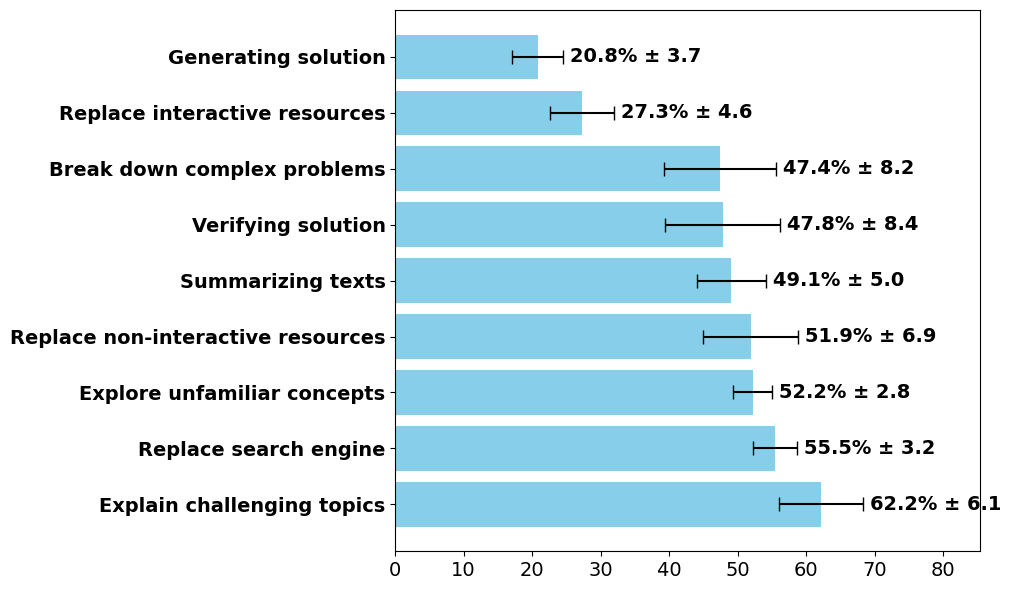

In [68]:
agggraph(categories, agg, cluster)

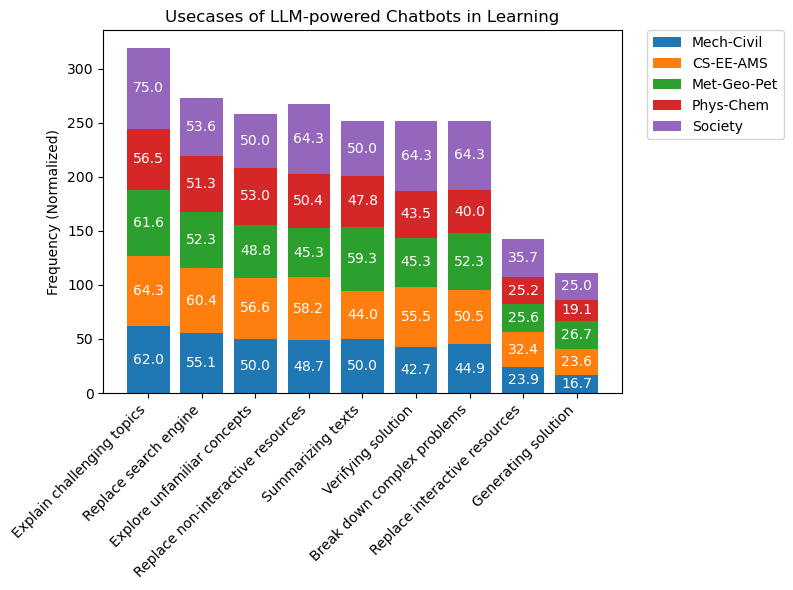

In [17]:
stacked_bar_graph(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Learning')

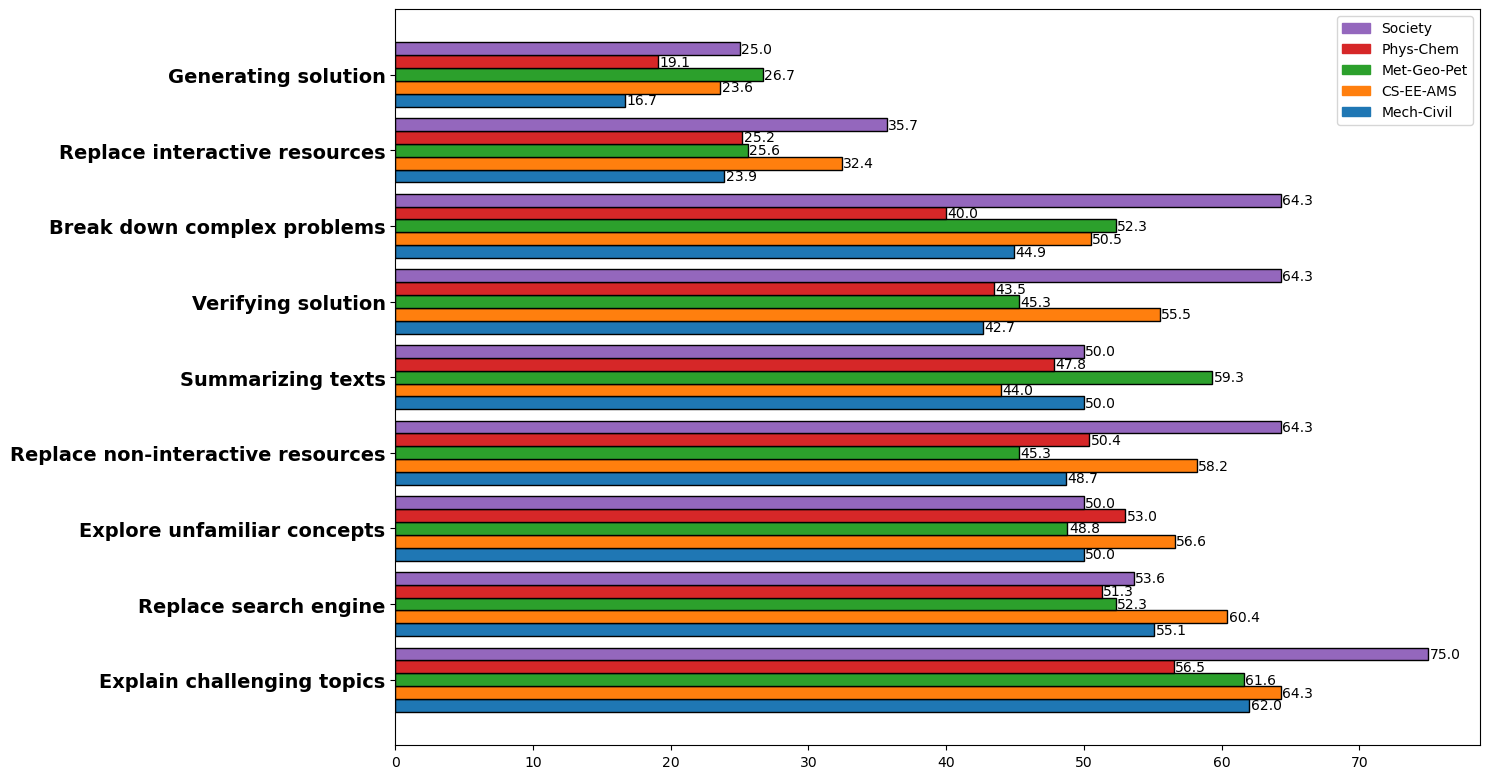

In [18]:
grouped_bar_graph_horizontal_color(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Learning', 15, 7.9) # 15X7.9

In [69]:
clear_vec()

In [70]:
c1, c2, c3, c4, c5 = create_vector(df, 51)

[0, 104, 113, 40, 42, 12]
[104]


In [71]:
c1, c2, c3, c4, c5 = create_vector(df, 49)

[0, 88, 107, 41, 33, 14]
[104, 88]


In [72]:
c1, c2, c3, c4, c5 = create_vector(df, 53)

[0, 50, 69, 27, 32, 6]
[104, 88, 50]


In [73]:
c1, c2, c3, c4, c5 = create_vector(df, 52)

[0, 51, 50, 27, 36, 7]
[104, 88, 50, 51]


In [74]:
c1, c2, c3, c4, c5 = create_vector(df, 50)

[0, 23, 41, 15, 15, 6]
[104, 88, 50, 51, 23]


In [75]:
c1_copy = c1
c2_copy = c2
c3_copy = c3
c4_copy = c4
c5_copy = c5


print(c1_copy)
print(c2_copy)
print(c3_copy)
print(c4_copy)
print(c5_copy)

agg = aggregated_count(c1, c2, c3, c4, c5)
print(agg)

for i in range (len(agg)):
    agg[i] = round((agg[i]/(234+182+86+115+28)*100), 1)
print(agg)

[104, 88, 50, 51, 23]
[113, 107, 69, 50, 41]
[40, 41, 27, 27, 15]
[42, 33, 32, 36, 15]
[12, 14, 6, 7, 6]
[311, 283, 184, 171, 100]
[48.2, 43.9, 28.5, 26.5, 15.5]


In [76]:
columns_to_check = [
    df.iloc[:, 40], df.iloc[:, 41], df.iloc[:, 42], df.iloc[:, 43], df.iloc[:, 44],
    df.iloc[:, 45], df.iloc[:, 46], df.iloc[:, 47], df.iloc[:, 48], df.iloc[:, 49],
    df.iloc[:, 50], df.iloc[:, 51], df.iloc[:, 52], df.iloc[:, 53], df.iloc[:, 54],
    df.iloc[:, 55], df.iloc[:, 56], df.iloc[:, 57], df.iloc[:, 58]
]
c1 = normalized_dept_cluster(df, c1, columns_to_check, 1)
c2 = normalized_dept_cluster(df, c2, columns_to_check, 2)
c3 = normalized_dept_cluster(df, c3, columns_to_check, 3)
c4 = normalized_dept_cluster(df, c4, columns_to_check, 4)
c5 = normalized_dept_cluster(df, c5, columns_to_check, 5)

print(c1)
print(c2)
print(c3)
print(c4)
print(c5)

234
182
86
115
28
[44.4, 37.6, 21.4, 21.8, 9.8]
[62.1, 58.8, 37.9, 27.5, 22.5]
[46.5, 47.7, 31.4, 31.4, 17.4]
[36.5, 28.7, 27.8, 31.3, 13.0]
[42.9, 50.0, 21.4, 25.0, 21.4]


In [77]:
categories = ['Debugging code', 'Explaining the behavior', 'Accelerating development', 'Drafting code', 'Converting code']

In [78]:
cluster = np.array([
    c1,
    c2,
    c3,
    c4,
    c5
])
print(cluster)

[[44.4 37.6 21.4 21.8  9.8]
 [62.1 58.8 37.9 27.5 22.5]
 [46.5 47.7 31.4 31.4 17.4]
 [36.5 28.7 27.8 31.3 13. ]
 [42.9 50.  21.4 25.  21.4]]


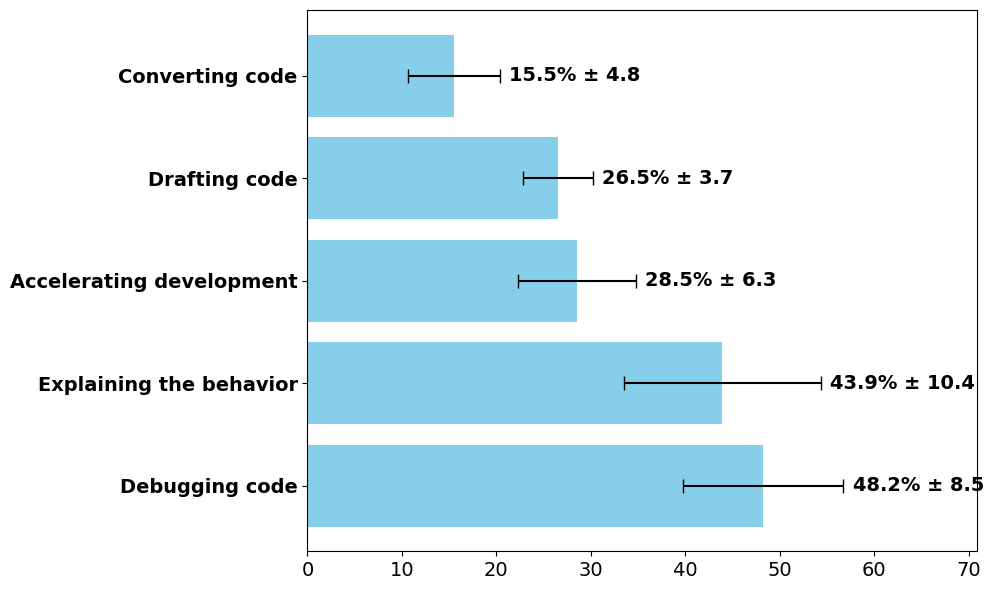

In [79]:
agggraph(categories, agg, cluster)

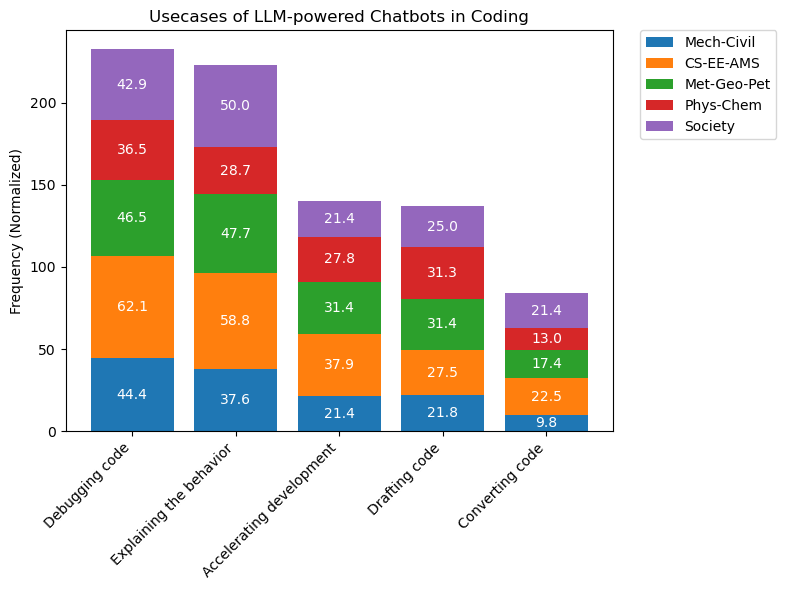

In [27]:
stacked_bar_graph(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Coding')

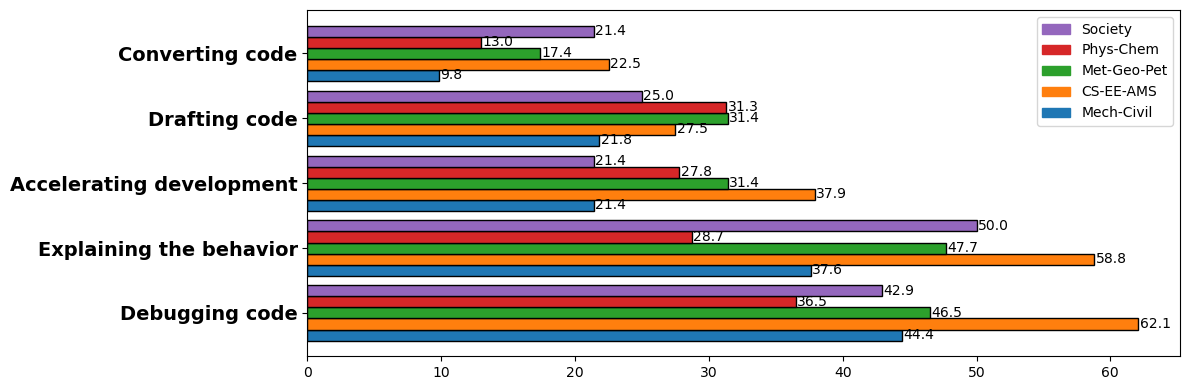

In [28]:
grouped_bar_graph_horizontal_color(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Coding', 12, 4) # 12X4

In [80]:
clear_vec()

In [81]:
c1, c2, c3, c4, c5 = create_vector(df, 54)

[0, 160, 102, 45, 60, 16]
[160]


In [82]:
c1, c2, c3, c4, c5 = create_vector(df, 58)

[0, 106, 82, 52, 47, 13]
[160, 106]


In [83]:
c1, c2, c3, c4, c5 = create_vector(df, 56)

[0, 84, 60, 25, 33, 14]
[160, 106, 84]


In [84]:
c1, c2, c3, c4, c5 = create_vector(df, 55)

[0, 55, 38, 25, 18, 14]
[160, 106, 84, 55]


In [85]:
c1, c2, c3, c4, c5 = create_vector(df, 57)

[0, 53, 31, 17, 18, 10]
[160, 106, 84, 55, 53]


In [86]:
c1_copy = c1
c2_copy = c2
c3_copy = c3
c4_copy = c4
c5_copy = c5


print(c1_copy)
print(c2_copy)
print(c3_copy)
print(c4_copy)
print(c5_copy)

agg = aggregated_count(c1, c2, c3, c4, c5)
print(agg)

for i in range (len(agg)):
    agg[i] = round((agg[i]/(234+182+86+115+28)*100), 1)
print(agg)

[160, 106, 84, 55, 53]
[102, 82, 60, 38, 31]
[45, 52, 25, 25, 17]
[60, 47, 33, 18, 18]
[16, 13, 14, 14, 10]
[383, 300, 216, 150, 129]
[59.4, 46.5, 33.5, 23.3, 20.0]


In [87]:
columns_to_check = [
    df.iloc[:, 40], df.iloc[:, 41], df.iloc[:, 42], df.iloc[:, 43], df.iloc[:, 44],
    df.iloc[:, 45], df.iloc[:, 46], df.iloc[:, 47], df.iloc[:, 48], df.iloc[:, 49],
    df.iloc[:, 50], df.iloc[:, 51], df.iloc[:, 52], df.iloc[:, 53], df.iloc[:, 54],
    df.iloc[:, 55], df.iloc[:, 56], df.iloc[:, 57], df.iloc[:, 58]
]
c1 = normalized_dept_cluster(df, c1, columns_to_check, 1)
c2 = normalized_dept_cluster(df, c2, columns_to_check, 2)
c3 = normalized_dept_cluster(df, c3, columns_to_check, 3)
c4 = normalized_dept_cluster(df, c4, columns_to_check, 4)
c5 = normalized_dept_cluster(df, c5, columns_to_check, 5)

print(c1)
print(c2)
print(c3)
print(c4)
print(c5)

234
182
86
115
28
[68.4, 45.3, 35.9, 23.5, 22.6]
[56.0, 45.1, 33.0, 20.9, 17.0]
[52.3, 60.5, 29.1, 29.1, 19.8]
[52.2, 40.9, 28.7, 15.7, 15.7]
[57.1, 46.4, 50.0, 50.0, 35.7]


In [88]:
categories = ['Brainstorming', 'Improving a draft','Outlining a document', 'Collecting resources',
             'Generating an initial draft']

In [89]:
cluster = np.array([
    c1,
    c2,
    c3,
    c4,
    c5
])
print(cluster)

[[68.4 45.3 35.9 23.5 22.6]
 [56.  45.1 33.  20.9 17. ]
 [52.3 60.5 29.1 29.1 19.8]
 [52.2 40.9 28.7 15.7 15.7]
 [57.1 46.4 50.  50.  35.7]]


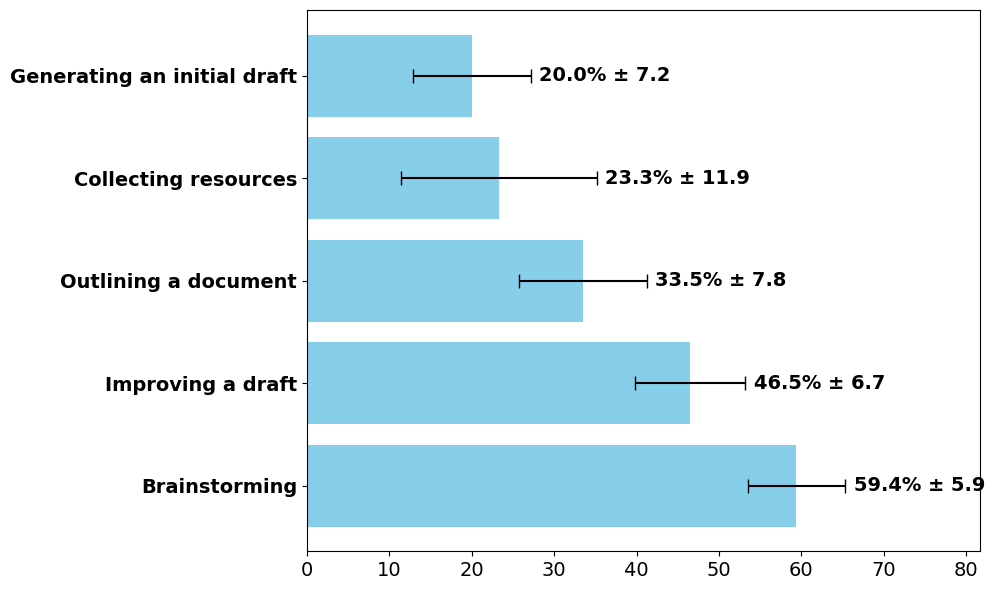

In [90]:
agggraph(categories, agg, cluster)

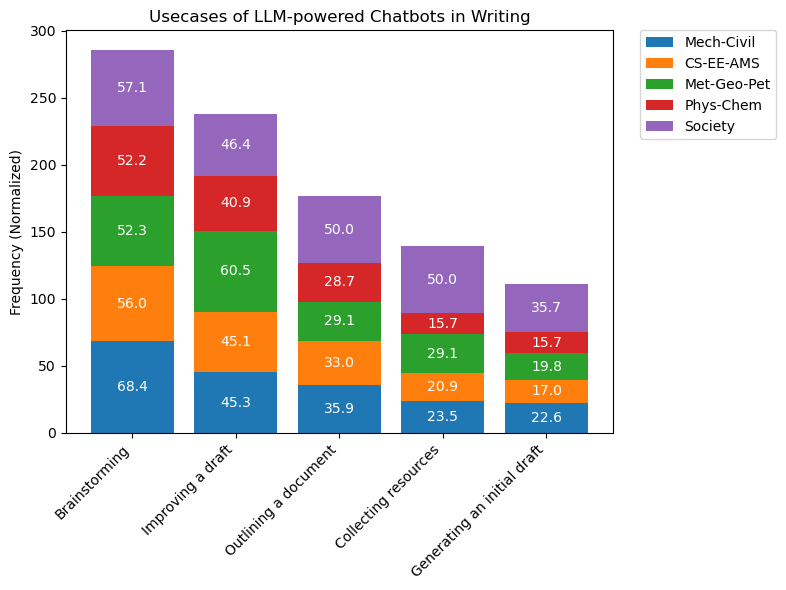

In [37]:
stacked_bar_graph(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Writing')

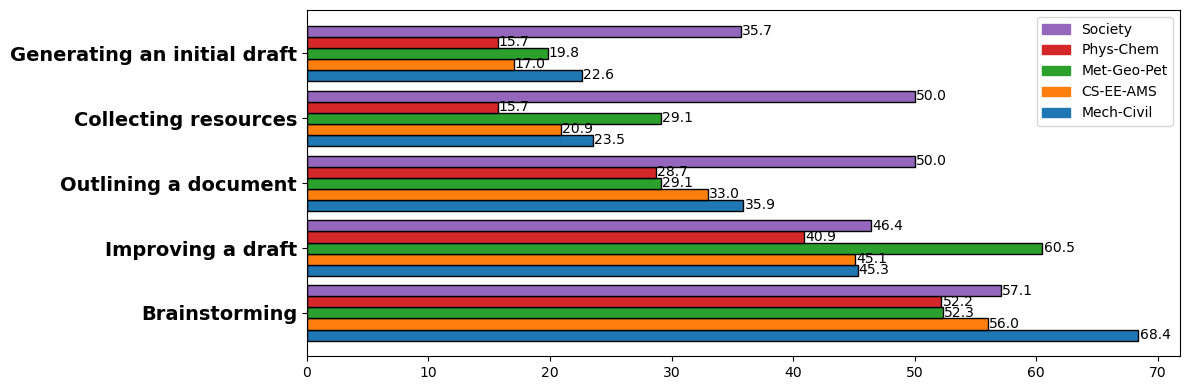

In [38]:
grouped_bar_graph_horizontal_color(categories, c1, c2, c3, c4, c5, 'Usecases of LLM-powered Chatbots in Writing', 12, 4)

In [39]:
clear_vec()

In [40]:
llm = create_degree_lists(df, 34, 5)
dept = df['What department or program are you in?']

In [41]:
from module import department_mapping

In [42]:
never = {dept_name: 0 for dept_name in department_mapping.values()}
never_att = llm[1]  

never = count_usage_cases(dept, never_att, never)

count = count_cluster_wise(never)

print(count)

pre_vec(count)

print(c1)

[0, 57, 33, 20, 42, 2]
[57]


In [43]:
once_twice = {dept_name: 0 for dept_name in department_mapping.values()}
once_twice_att = llm[2]  

once_twice = count_usage_cases(dept, once_twice_att, once_twice)

count = count_cluster_wise(once_twice)

print(count)

pre_vec(count)

print(c1)

[0, 106, 71, 31, 46, 9]
[57, 106]


In [44]:
regular = {dept_name: 0 for dept_name in department_mapping.values()}
regular_att = llm[3]  

regular = count_usage_cases(dept, regular_att, regular)

count = count_cluster_wise(regular)

print(count)

pre_vec(count)

print(c1)

[0, 106, 67, 36, 56, 13]
[57, 106, 106]


In [45]:
all = {dept_name: 0 for dept_name in department_mapping.values()}
all_att = llm[4]  

rall = count_usage_cases(dept, all_att, all)

count = count_cluster_wise(rall)

print(count)

pre_vec(count)

print(c1)

[0, 24, 47, 19, 14, 6]
[57, 106, 106, 24]


In [46]:
fun = {dept_name: 0 for dept_name in department_mapping.values()}
fun_att = llm[5]  

fun = count_usage_cases(dept, fun_att, fun)

count = count_cluster_wise(fun)

print(count)

pre_vec(count)

print(c1)

[0, 22, 15, 7, 9, 4]
[57, 106, 106, 24, 22]


In [47]:
v1 = []
v2 = []
v3 = []
v4 = []
v5 = []

In [48]:
v1 = c1.copy()
c1 = nordept(c1)
print(c1)

[18.1, 33.7, 33.7, 7.6, 7.0]


In [49]:
v2 = c2.copy()
c2 = nordept(c2)
print(c2)

[14.2, 30.5, 28.8, 20.2, 6.4]


In [50]:
v3 = c3.copy()
c3 = nordept(c3)
print(c3)

[17.7, 27.4, 31.9, 16.8, 6.2]


In [51]:
v4 = c4.copy()
c4 = nordept(c4)
print(c4)

[25.1, 27.5, 33.5, 8.4, 5.4]


In [52]:
v5 = c5.copy()
c5 = nordept(c5)
print(c5)

[5.9, 26.5, 38.2, 17.6, 11.8]


In [53]:
categories = ['Never', 'Irregular Users', 'Regular Users', 'Superusers', 'Having fun']


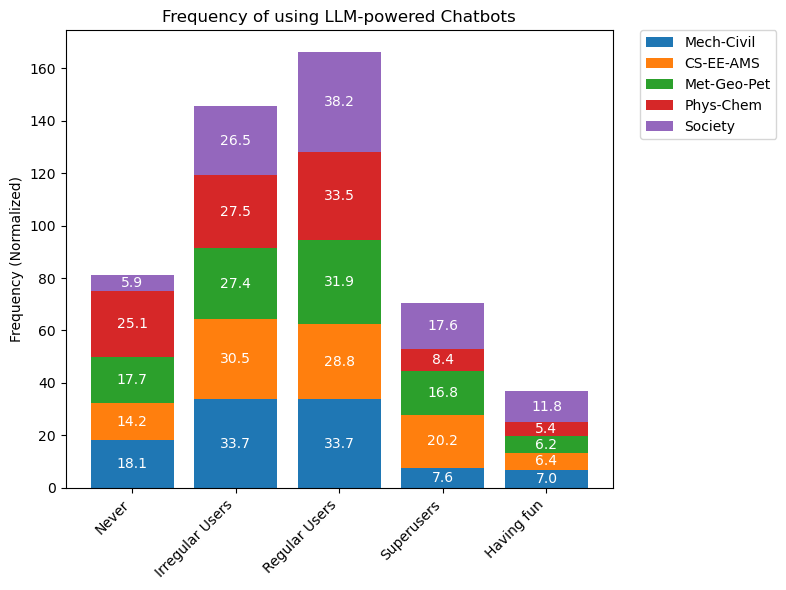

In [54]:
stacked_bar_graph(categories, c1, c2, c3, c4, c5, 'Frequency of using LLM-powered Chatbots')

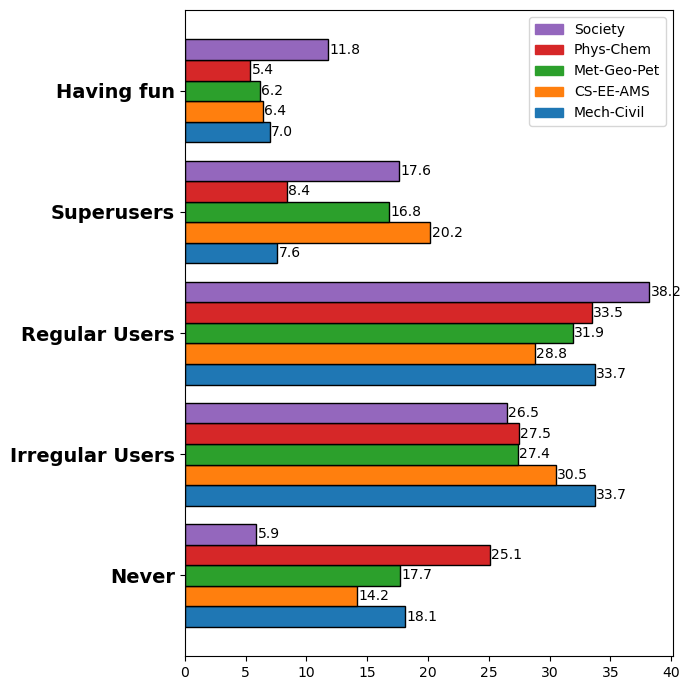

In [55]:
grouped_bar_graph_horizontal_color(categories, c1, c2, c3, c4, c5, 'Frequency of using LLM-powered Chatbots',7,7) # size 7X7, font 16

In [56]:
clear_vec()

In [57]:
misinfo = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

miss_att = df.iloc[:, 85]  

misinfo = count_usage_cases(dept, miss_att, misinfo)

count = count_cluster_wise(misinfo)

print(count)

pre_vec(count)

print(c1)

[0, 232, 162, 87, 125, 23]
[232]


In [58]:
dis = {dept_name: 0 for dept_name in department_mapping.values()}

dis_att = df.iloc[:, 88] 

dis = count_usage_cases(dept, dis_att, dis)


count = count_cluster_wise(dis)

print(count)

pre_vec(count)

print(c1)

[0, 158, 129, 70, 96, 14]
[232, 158]


In [59]:
bis = {dept_name: 0 for dept_name in department_mapping.values()}

bis_att = df.iloc[:, 92] 

bis = count_usage_cases(dept, bis_att, bis)


count = count_cluster_wise(bis)

print(count)

pre_vec(count)

print(c1)

[0, 110, 93, 36, 44, 13]
[232, 158, 110]


In [60]:
job = {dept_name: 0 for dept_name in department_mapping.values()}

job_att = df.iloc[:, 89] 

job = count_usage_cases(dept, job_att, job)


count = count_cluster_wise(job)

print(count)

pre_vec(count)

print(c1)

[0, 70, 68, 29, 40, 6]
[232, 158, 110, 70]


In [61]:
privacy = {dept_name: 0 for dept_name in department_mapping.values()}

privacy_att = df.iloc[:, 87] 

privacy = count_usage_cases(dept, privacy_att, privacy)


count = count_cluster_wise(privacy)

print(count)

pre_vec(count)

print(c1)

[0, 72, 55, 29, 40, 7]
[232, 158, 110, 70, 72]


In [62]:
sc = {dept_name: 0 for dept_name in department_mapping.values()}

sc_att = df.iloc[:, 94] 

sc = count_usage_cases(dept, sc_att, sc)


count = count_cluster_wise(sc)

print(count)

pre_vec(count)

print(c1)

[0, 63, 36, 18, 31, 11]
[232, 158, 110, 70, 72, 63]


In [63]:
ci = {dept_name: 0 for dept_name in department_mapping.values()}

ci_att = df.iloc[:, 86] 

ci = count_usage_cases(dept, ci_att, ci)


count = count_cluster_wise(ci)

print(count)

pre_vec(count)

print(c1)

[0, 44, 43, 16, 27, 2]
[232, 158, 110, 70, 72, 63, 44]


In [64]:
wr = {dept_name: 0 for dept_name in department_mapping.values()}

wr_att = df.iloc[:, 90] 

wr = count_usage_cases(dept, wr_att, wr)


count = count_cluster_wise(wr)

print(count)

pre_vec(count)

print(c1)

[0, 58, 32, 11, 18, 1]
[232, 158, 110, 70, 72, 63, 44, 58]


In [65]:
d = {dept_name: 0 for dept_name in department_mapping.values()}

d_att = df.iloc[:, 93] 

d = count_usage_cases(dept, d_att, d)


count = count_cluster_wise(d)

print(count)

pre_vec(count)

print(c1)

[0, 36, 18, 9, 19, 8]
[232, 158, 110, 70, 72, 63, 44, 58, 36]


In [66]:
dd = {dept_name: 0 for dept_name in department_mapping.values()}

dd_att = df.iloc[:, 91] 

dd = count_usage_cases(dept, dd_att, dd)


count = count_cluster_wise(dd)

print(count)

pre_vec(count)

print(c1)

[0, 14, 17, 5, 17, 3]
[232, 158, 110, 70, 72, 63, 44, 58, 36, 14]


In [67]:
sc = {dept_name: 0 for dept_name in department_mapping.values()}

sc_att = df.iloc[:, 95] 

sc = count_usage_cases(dept, sc_att, sc)


count = count_cluster_wise(sc)

print(count)

pre_vec(count)

print(c1)

[0, 9, 4, 5, 5, 5]
[232, 158, 110, 70, 72, 63, 44, 58, 36, 14, 9]


In [68]:
columns_to_check = [
    df.iloc[:, 85], df.iloc[:, 86], df.iloc[:, 87], df.iloc[:, 88], df.iloc[:, 89],
    df.iloc[:, 90], df.iloc[:, 91], df.iloc[:, 92], df.iloc[:, 93], df.iloc[:, 94],
    df.iloc[:, 95]
]
c1 = normalized_dept_cluster(df, c1, columns_to_check, 1)
c2 = normalized_dept_cluster(df, c2, columns_to_check, 2)
c3 = normalized_dept_cluster(df, c3, columns_to_check, 3)
c4 = normalized_dept_cluster(df, c4, columns_to_check, 4)
c5 = normalized_dept_cluster(df, c5, columns_to_check, 5)

print(c1)
print(c2)
print(c3)
print(c4)
print(c5)

315
233
113
167
34
[73.7, 50.2, 34.9, 22.2, 22.9, 20.0, 14.0, 18.4, 11.4, 4.4, 2.9]
[69.5, 55.4, 39.9, 29.2, 23.6, 15.5, 18.5, 13.7, 7.7, 7.3, 1.7]
[77.0, 61.9, 31.9, 25.7, 25.7, 15.9, 14.2, 9.7, 8.0, 4.4, 4.4]
[74.9, 57.5, 26.3, 24.0, 24.0, 18.6, 16.2, 10.8, 11.4, 10.2, 3.0]
[67.6, 41.2, 38.2, 17.6, 20.6, 32.4, 5.9, 2.9, 23.5, 8.8, 14.7]


In [69]:
categories = ['Misinfo.', 'Dishonest Use', 'Biased Training Data', 'Job Loss', 'Privacy breaches',
             'Reducing social connection', 'Climate Impact', 'Power concentration', 'Biased Outputs',
             'Increase digital divide', 'No concerns']

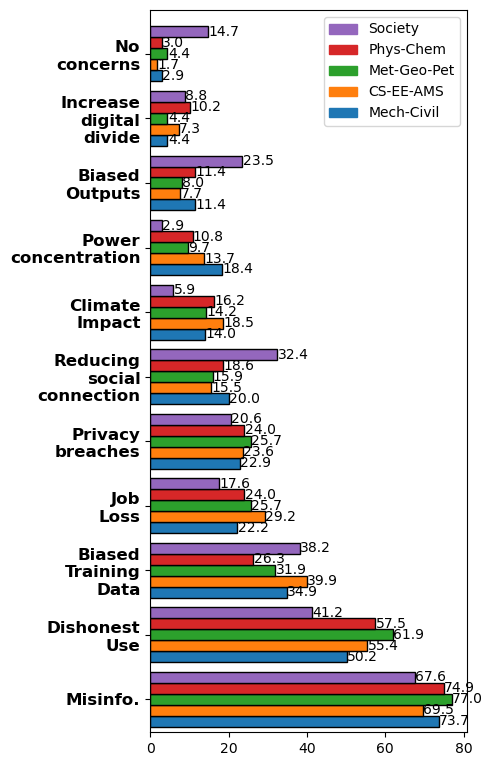

In [70]:
grouped_bar_graph_horizontal_color_white(categories, c1, c2, c3, c4, c5, 'Concerns regarding GenAI', 5, 8) # size 5 X 8, font 12, updated size 5X8

In [71]:
clear_vec()

In [72]:
ic = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

ic_att = df.iloc[:, 77]  

ic = count_usage_cases(dept, ic_att, ic)

count = count_cluster_wise(ic)

print(count)

pre_vec(count)

print(c1)

[0, 21, 40, 7, 10, 4]
[21]


In [73]:
iq = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

iq_att = df.iloc[:, 76]  

iq = count_usage_cases(dept, iq_att, iq)

count = count_cluster_wise(iq)

print(count)

pre_vec(count)

print(c1)

[0, 18, 20, 7, 9, 3]
[21, 18]


In [74]:
cu = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

cu_att = df.iloc[:, 79]  

cu = count_usage_cases(dept, cu_att, cu)

count = count_cluster_wise(cu)

print(count)

pre_vec(count)

print(c1)

[0, 20, 17, 4, 5, 1]
[21, 18, 20]


In [75]:
it = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

it_att = df.iloc[:, 74]  

it = count_usage_cases(dept, it_att, it)

count = count_cluster_wise(it)

print(count)

pre_vec(count)

print(c1)

[0, 14, 14, 4, 7, 3]
[21, 18, 20, 14]


In [76]:
kp = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

kp_att = df.iloc[:, 78]  

kp = count_usage_cases(dept, kp_att, kp)

count = count_cluster_wise(kp)

print(count)

pre_vec(count)

print(c1)

[0, 10, 20, 1, 2, 0]
[21, 18, 20, 14, 10]


In [77]:
ip = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

ip_att = df.iloc[:, 73]  

ip = count_usage_cases(dept, ip_att, ip)

count = count_cluster_wise(ip)

print(count)

pre_vec(count)

print(c1)

[0, 9, 9, 2, 6, 2]
[21, 18, 20, 14, 10, 9]


In [78]:
nd = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

nd_att = df.iloc[:, 72]  

nd = count_usage_cases(dept, nd_att, nd)

count = count_cluster_wise(nd)

print(count)

pre_vec(count)

print(c1)

[0, 5, 8, 2, 8, 3]
[21, 18, 20, 14, 10, 9, 5]


In [79]:
icq = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

icq_att = df.iloc[:, 75]  

icq = count_usage_cases(dept, icq_att, icq)

count = count_cluster_wise(icq)

print(count)

pre_vec(count)

print(c1)

[0, 7, 9, 2, 3, 3]
[21, 18, 20, 14, 10, 9, 5, 7]


In [80]:
bo = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

bo_att = df.iloc[:, 70]  

bo = count_usage_cases(dept, bo_att, bo)

count = count_cluster_wise(bo)

print(count)

pre_vec(count)

print(c1)

[0, 5, 6, 3, 7, 2]
[21, 18, 20, 14, 10, 9, 5, 7, 5]


In [81]:
nt = {dept_name: 0 for dept_name in department_mapping.values()}
dept = df['What department or program are you in?']

nt_att = df.iloc[:, 71]  

nt = count_usage_cases(dept, nt_att, nt)

count = count_cluster_wise(nt)

print(count)

pre_vec(count)

print(c1)

[0, 4, 3, 2, 1, 0]
[21, 18, 20, 14, 10, 9, 5, 7, 5, 4]


In [82]:
columns_to_check = [
    df.iloc[:, 70], df.iloc[:, 71], df.iloc[:, 72], df.iloc[:, 73], df.iloc[:, 74],
    df.iloc[:, 75], df.iloc[:, 76], df.iloc[:, 77], df.iloc[:, 78], df.iloc[:, 79]
]
c1 = normalized_dept_cluster(df, c1, columns_to_check, 1)
c2 = normalized_dept_cluster(df, c2, columns_to_check, 2)
c3 = normalized_dept_cluster(df, c3, columns_to_check, 3)
c4 = normalized_dept_cluster(df, c4, columns_to_check, 4)
c5 = normalized_dept_cluster(df, c5, columns_to_check, 5)

print(c1)
print(c2)
print(c3)
print(c4)
print(c5)

43
54
13
23
7
[48.8, 41.9, 46.5, 32.6, 23.3, 20.9, 11.6, 16.3, 11.6, 9.3]
[74.1, 37.0, 31.5, 25.9, 37.0, 16.7, 14.8, 16.7, 11.1, 5.6]
[53.8, 53.8, 30.8, 30.8, 7.7, 15.4, 15.4, 15.4, 23.1, 15.4]
[43.5, 39.1, 21.7, 30.4, 8.7, 26.1, 34.8, 13.0, 30.4, 4.3]
[57.1, 42.9, 14.3, 42.9, 0.0, 28.6, 42.9, 42.9, 28.6, 0.0]


In [83]:
categories = ['Improving depth of knowledge', 'Improving quality of work', 'Curious for new tech', 'Increase time for other works',
             'Keeping up with latest tools', 'Increasing time for personal life', 'To earn good grade', 'Improving creativity', 
             'Being too overwhelmed', 'Not seening value']



In [84]:
categories = [
    'Depth of knowledge',  # Shortened from 'Improving depth of knowledge'
    'Quality of work',     # Shortened from 'Improving quality of work'
    'Curiosity for tech',  # Shortened from 'Curious for new tech'
    'More time for work',  # Shortened from 'Increase time for other works'
    'Staying updated',     # Shortened from 'Keeping up with latest tools'
    'Time for personal life',  # Simplified from 'Increasing time for personal life'
    'Earning good grades',     # Simplified from 'To earn good grade'
    'Improving creativity',     # Simplified from 'Improving creativity'
    'Being too overwhelmed',     # Simplified from 'Being too overwhelmed'
    'Not seeing value'         # Simplified from 'Not seening value'
]

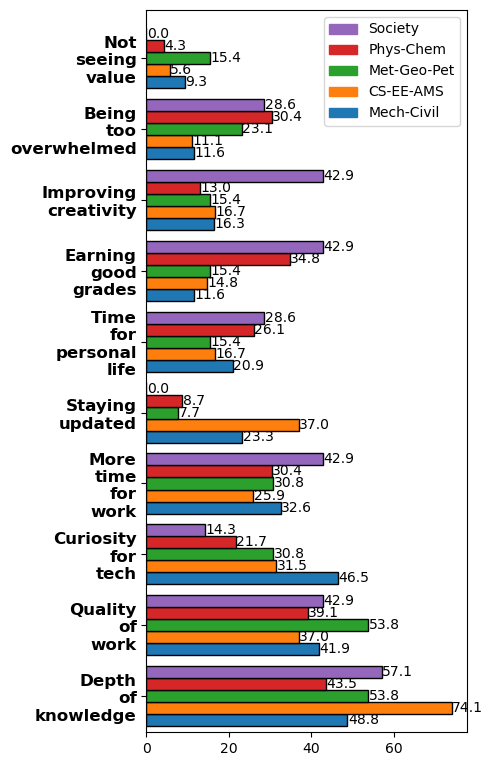

In [85]:
grouped_bar_graph_horizontal_color_white(categories, c1, c2, c3, c4, c5, 'Motivayion of using LLM-powered chatbots', 5, 8) 

236
185
86
116
28


/Users/jesanahammed/GenAI 2024/note_books/../scripts/plots.py:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


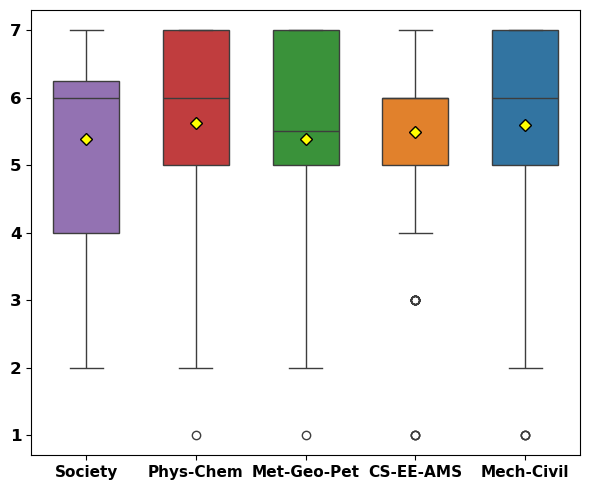

In [86]:
dept_number = df['What department or program are you in?']  # Get department number
ethical_score = df.iloc[:, 69]  # Get ethical score

scores_mech, scores_cs, scores_met, scores_phys, scores_society = culster_wise_val(dept_number, ethical_score)

print(len(scores_mech))
print(len(scores_cs))
print(len(scores_met))
print(len(scores_phys))
print(len(scores_society))


custom_palette = {
    'Mech-Civil': '#1f77b4',
    'CS-EE-AMS': '#ff7f0e',
    'Met-Geo-Pet': '#2ca02c',
    'Phys-Chem': '#d62728',
    'Society': '#9467bd'
}
# Reverse the order of departments
departments_reversed = ['Society', 'Phys-Chem', 'Met-Geo-Pet', 'CS-EE-AMS', 'Mech-Civil']

# Combine into a DataFrame with reversed department order
data = {
    'Department': (['Society'] * len(scores_society) +
                   ['Phys-Chem'] * len(scores_phys) +
                   ['Met-Geo-Pet'] * len(scores_met) +
                   ['CS-EE-AMS'] * len(scores_cs) +
                   ['Mech-Civil'] * len(scores_mech)),
    'Ethical_Score': scores_society + scores_phys + scores_met + scores_cs + scores_mech
}

df_new = pd.DataFrame(data)

boxplot(custom_palette, df_new, departments_reversed)

1


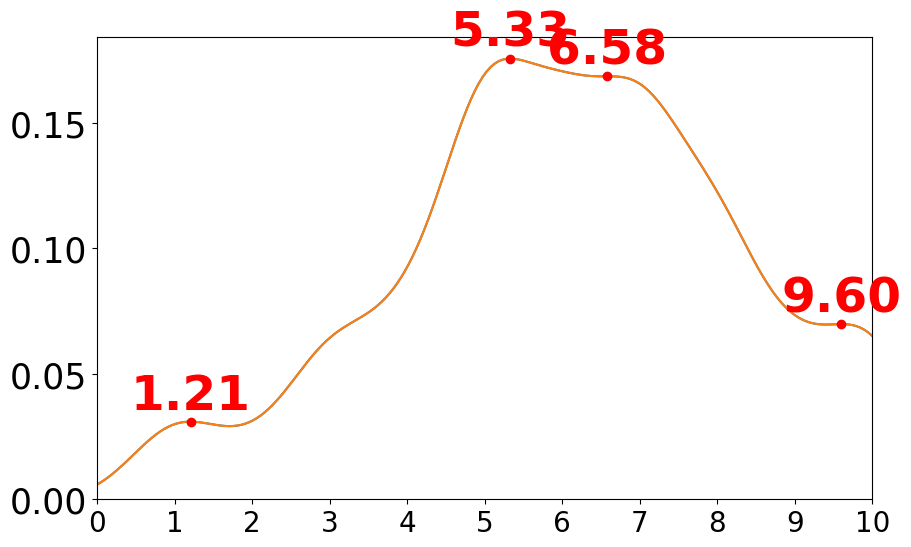

Peak values are at: [1.20603015 5.32663317 6.58291457 9.59798995]


In [5]:
scientific_major = df.iloc[:, 61]
print(scientific_major.isna().sum())
kde_plot(scientific_major, 0, 10, 0.001, 11, 'Scientific major 2024.png', "Estimation", "Density") # peak font size 25

1


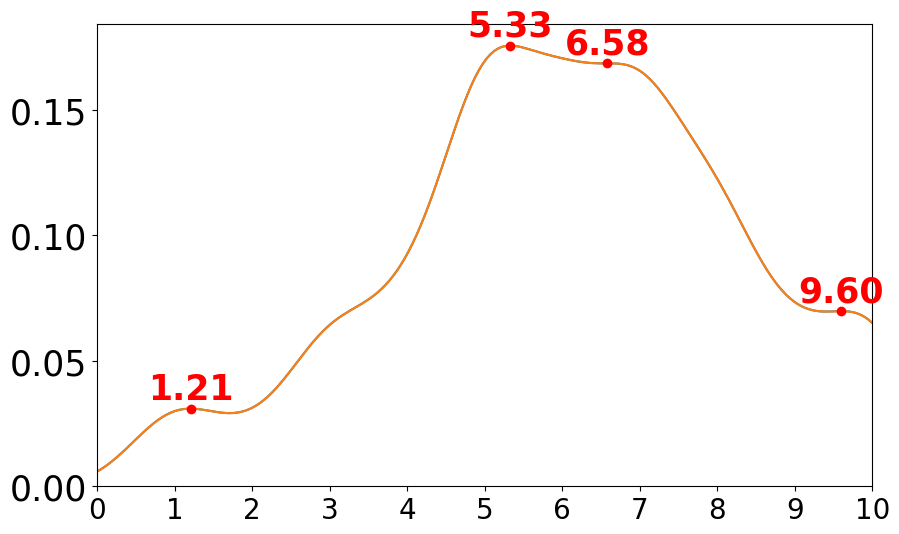

Peak values are at: [1.20603015 5.32663317 6.58291457 9.59798995]


In [87]:
scientific_major = df.iloc[:, 61]
print(scientific_major.isna().sum())
kde_plot(scientific_major, 0, 10, 0.001, 11, 'Scientific major 2024.png', "Estimation", "Density") # peak font size 25

In [7]:
file_path = '/Users/jesanahammed/Desktop/dataset/MOD - RAW - GenAI Survey Responses(Text).csv'
df_2023 = pd.read_csv(file_path, encoding='latin1')

In [8]:
df_2023_cleaned = df_2023.dropna(subset=['What department or program are you in?', 
                                         'What degree are you enrolled in?', 
                                         'How many years have you been at Mines?'])

# Reset the index and drop the old index column
df_2023_cleaned.reset_index(drop=True, inplace=True)

print(len(df_2023_cleaned['What department or program are you in?']))


601


In [9]:
ben_sci_2023 = df_2023_cleaned['Please rate your current feelings on whether generative AI will be beneficial or harmful for your field.']

In [10]:
mapping = {
    '7': 7,
    '9': 9,
    '6': 6,
    '8': 8,
    '5': 5,
    '10 (Extremely beneficial)': 10,
    '4': 4,
    '3': 3,
    '1 (Extremely harmful)': 1,
    '2': 2
}

# Convert the values to numeric using the mapping
ben_sci_2023_numeric = ben_sci_2023.replace(mapping).astype(int)

# Check the result
print(ben_sci_2023_numeric.unique())

[ 7  9  6  8  5 10  4  3  1  2]


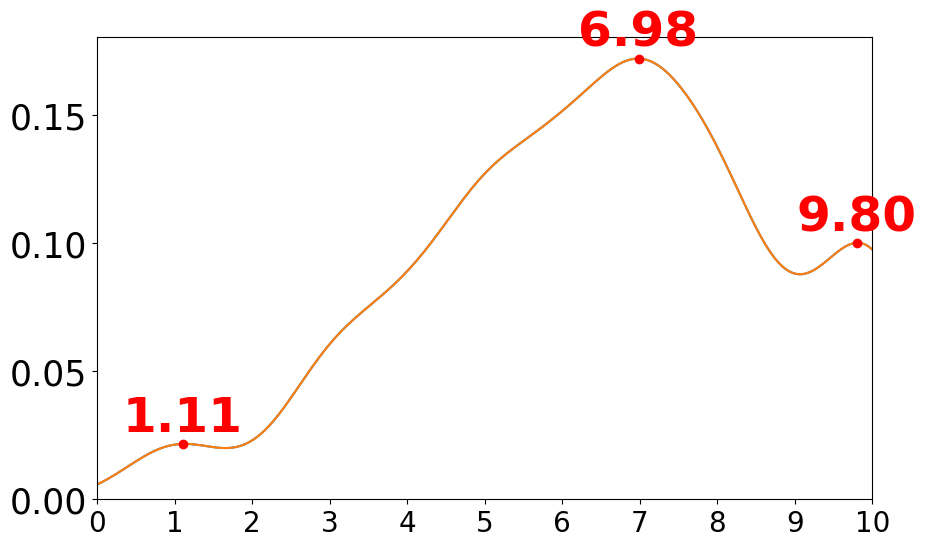

Peak values are at: [1.10552764 6.98492462 9.79899497]


In [11]:
kde_plot(ben_sci_2023_numeric, 0, 10, 0.001, 11, 'Scientific major 2023.png', "Estimation", "Density")

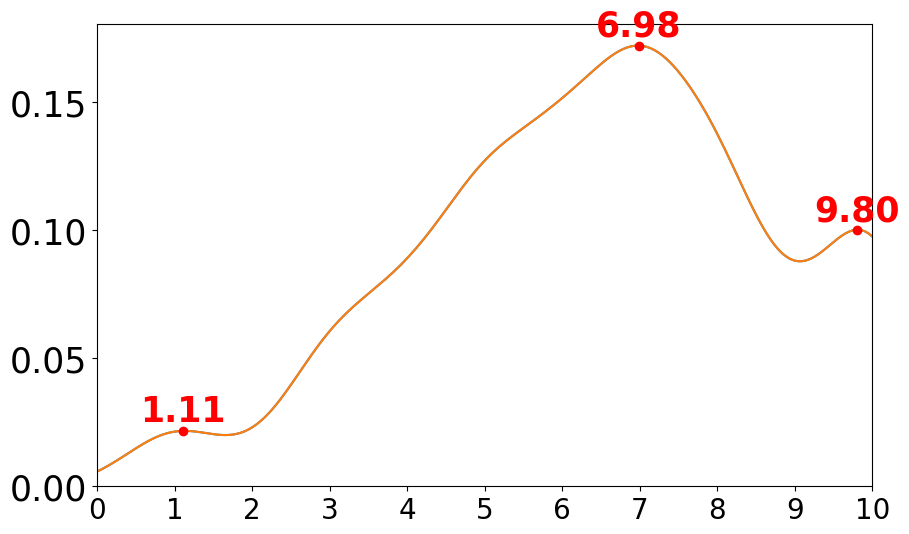

Peak values are at: [1.10552764 6.98492462 9.79899497]


In [92]:
kde_plot(ben_sci_2023_numeric, 0, 10, 0.001, 11, 'Scientific major 2023.png', "Estimation", "Density")

0


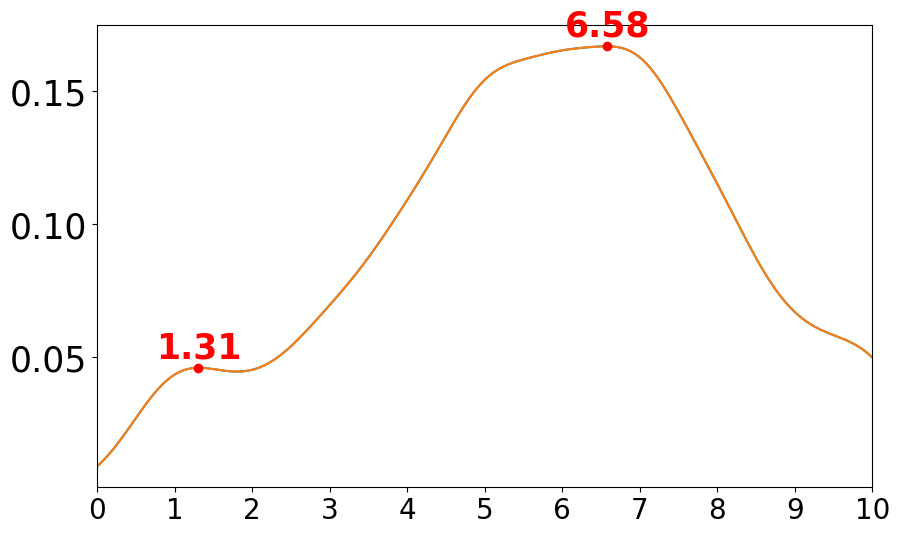

Peak values are at: [1.30653266 6.58291457]


In [93]:
learning_higher = df.iloc[:, 62]
print(learning_higher.isna().sum())
kde_plot(learning_higher, 0, 10, 0.001, 11, "Learning during higher education", "Estimation", "Density") # peak font size 35

0


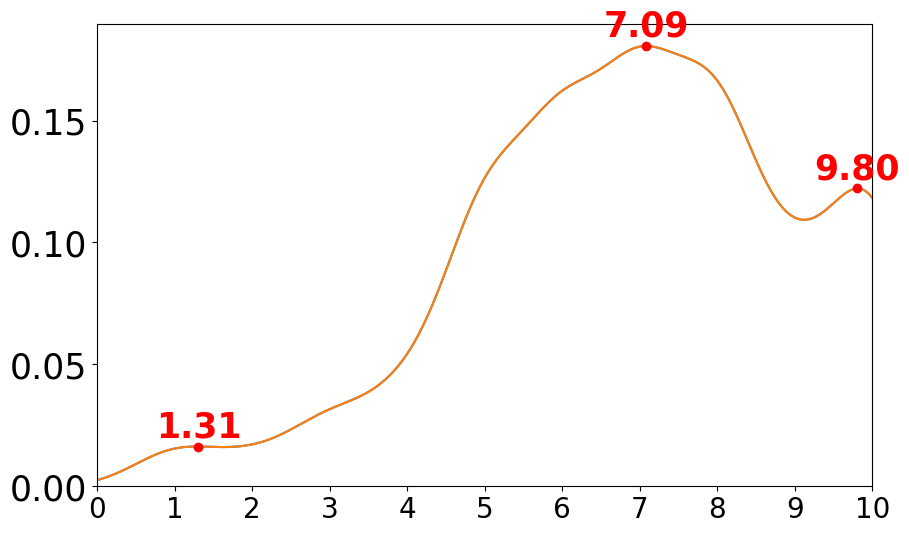

Peak values are at: [1.30653266 7.08542714 9.79899497]


In [94]:
efficiency_completing_task = df.iloc[:, 63]
print(efficiency_completing_task.isna().sum())
kde_plot(efficiency_completing_task, 0, 10, 0.001, 11,  "efficiency at completing tasks", "Estimation", "Density")

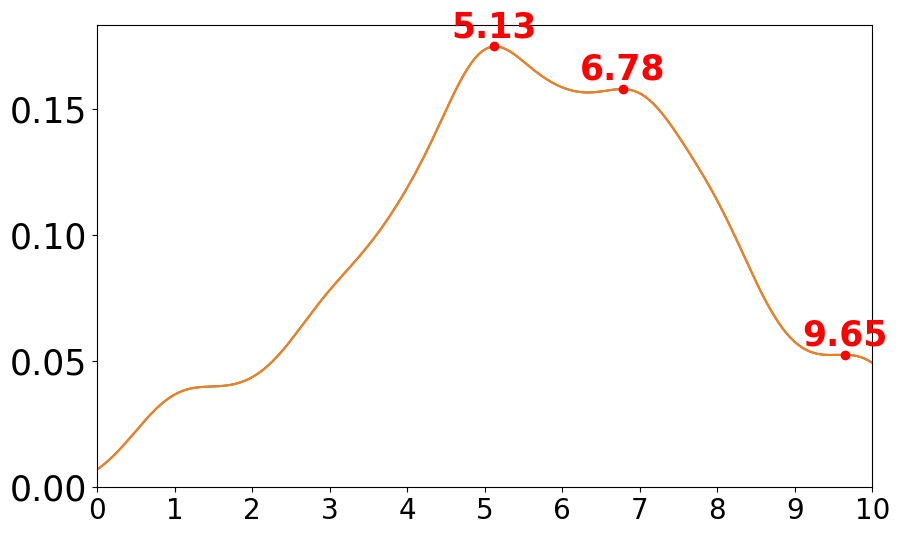

Peak values are at: [5.12562814 6.7839196  9.64824121]


In [95]:
quality = df.iloc[:, 64]
#print(scientific_major)
kde_plot(quality, 0, 10, 0.001, 11, "Quality of the completed tasks", "Estimation", "Density")

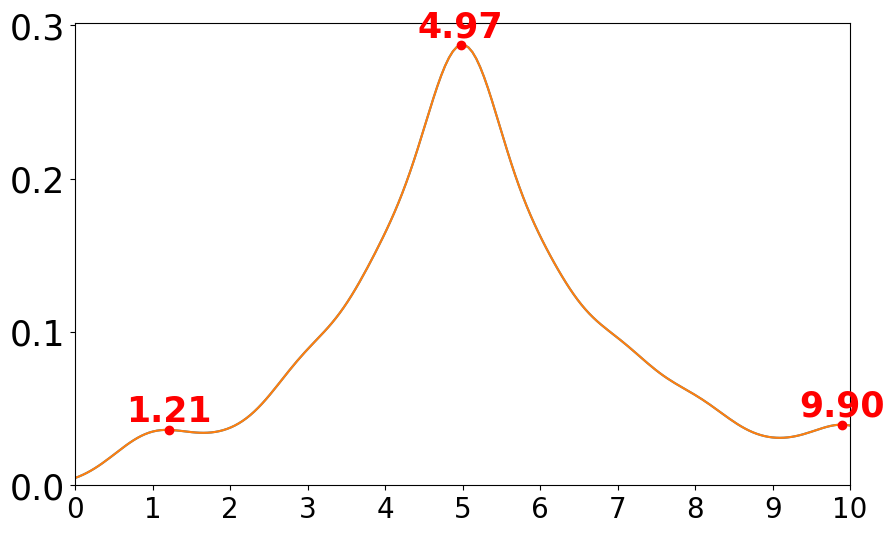

Peak values are at: [1.20603015 4.97487437 9.89949749]


In [96]:
job_placement = df.iloc[:, 65]
#print(scientific_major)
kde_plot(job_placement, 0, 10, 0.001, 11,  "Job placement after Graduation", "Estimation", "Density")

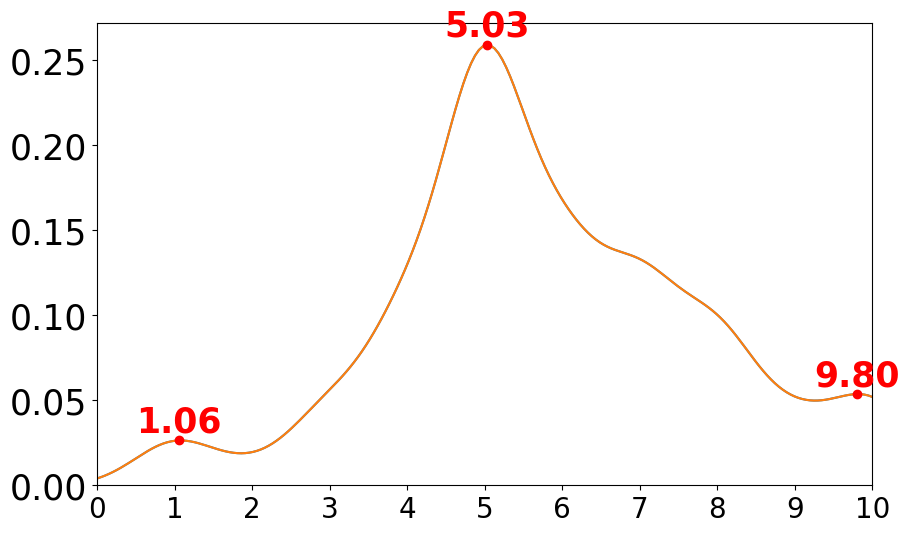

Peak values are at: [1.05527638 5.02512563 9.79899497]


In [97]:
intended_job = df.iloc[:, 66]
#print(scientific_major)
kde_plot(intended_job, 0, 10, 0.001, 11, "Intended job after graduating", "Estimation", "Density")

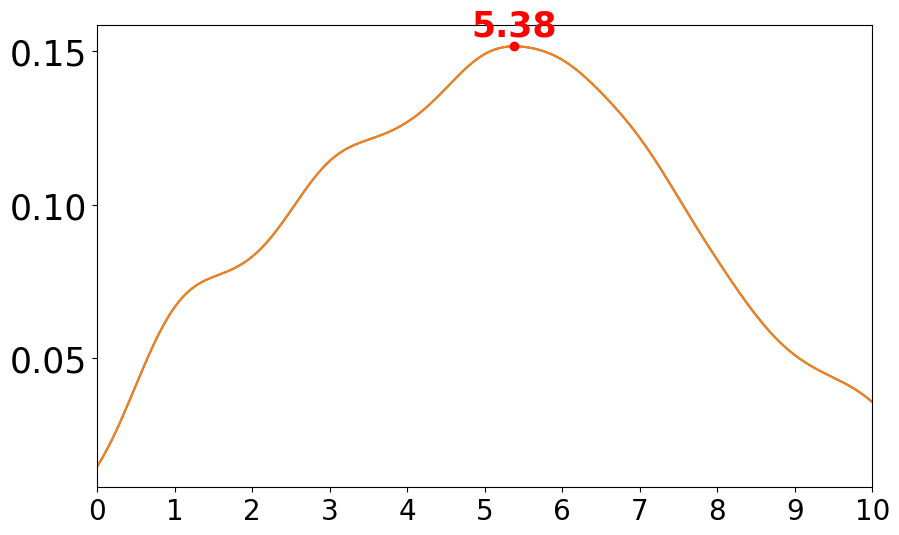

Peak values are at: [5.37688442]


In [98]:
socity = df.iloc[:, 67]
#print(scientific_major)
kde_plot(socity, 0, 10, 0.001, 11, "Socity at large", "Estimation", "Density")

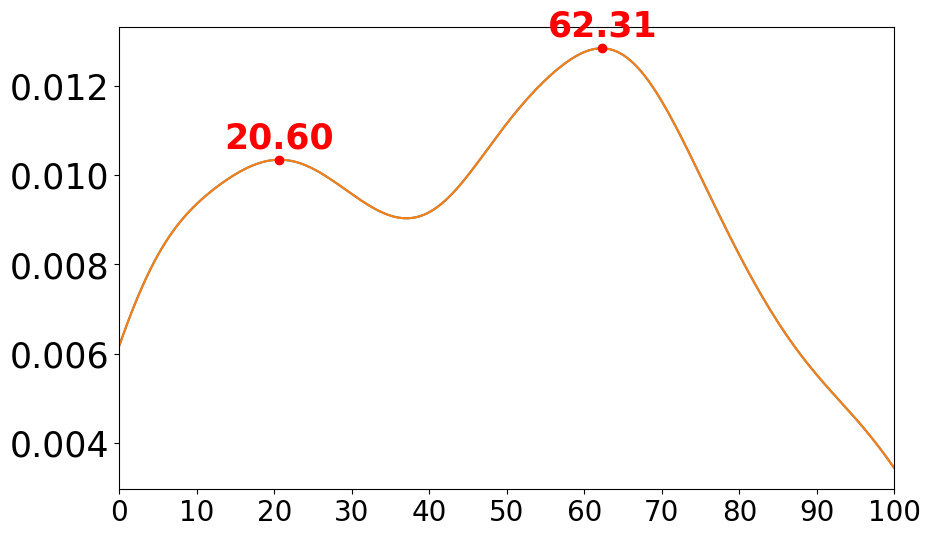

Peak values are at: [20.60301508 62.31155779]


In [99]:
p_doom2 = df['Impact of P(doom)']
kde_plot(p_doom2, 0, 100, 0.0001, 11, "Estimation on P(doom)", "Estimation", "Density")

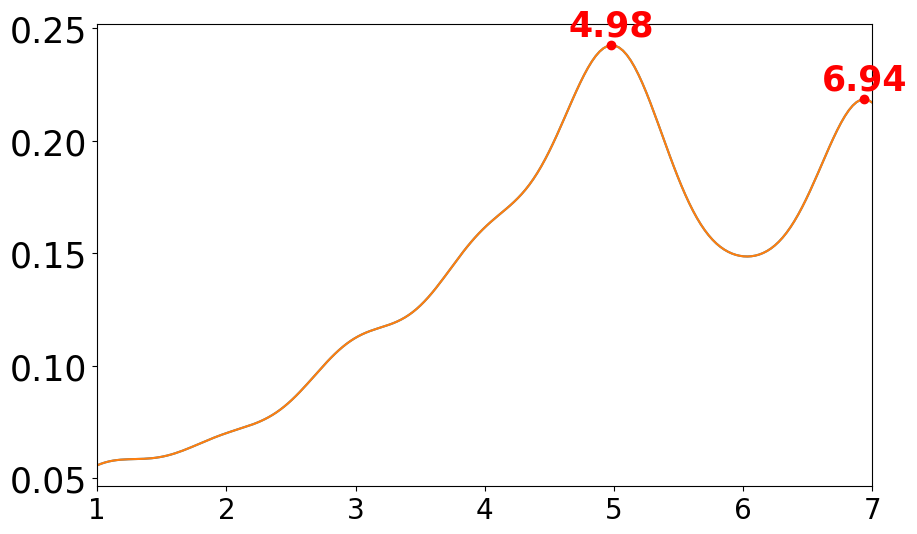

Peak values are at: [4.9798995  6.93969849]


In [100]:
imp_p_2 = df['Importance of P(doom)']
kde_plot(imp_p_2, 1, 7, 0.001, 7,  "Estimation on P(doom)", "Estimation", "Density")

In [101]:
rating_sci = df['Your scientific field or major']
freq = df['LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)']

In [102]:
contigency_table = create_con_table(rating_sci, freq)
print(contigency_table)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
Your scientific field or major                                                 
1.0                                                           18  11   1   0   
2.0                                                            9   4   2   1   
3.0                                                           21  20  10   1   
4.0                                                           16  31  10   3   
5.0                                                           35  64  41  14   
6.0                                                           20  44  64   9   
7.0                                                           18  45  56  19   
8.0                                                            8  29  39  26   
9.0                                                            5   7  26  12   
10.0                                                           4   7  29  25   

LLM-powered chatbots (e.g. ChatGPT Gemi

In [103]:
observed, expected = chi_square_test(contigency_table)

Chi-Square Statistic: 208.7490
P-Value: 3.2511341843664216e-26
Degrees of Freedom: 36
Expected Frequencies:
[[ 5.90243902 10.04181185 10.65505226  4.21602787  2.18466899]
 [ 3.2195122   5.47735192  5.81184669  2.29965157  1.19163763]
 [10.91056911 18.56213705 19.69570267  7.79326365  4.03832753]
 [11.62601626 19.77932636 20.98722416  8.30429733  4.30313589]
 [29.33333333 49.9047619  52.95238095 20.95238095 10.85714286]
 [25.39837398 43.21022067 45.84901278 18.1416957   9.40069686]
 [26.82926829 45.6445993  48.43205575 19.16376307  9.93031359]
 [19.13821138 32.55981417 34.54819977 13.67015099  7.08362369]
 [ 9.30081301 15.82346109 16.78977933  6.64343786  3.44250871]
 [12.34146341 20.99651568 22.27874564  8.81533101  4.56794425]]
There is a significant relationship


In [104]:
residuals_cal(observed, expected)

Standardized Residuals:
[[ 4.9794579   0.30237422 -2.9578547  -2.05329683  0.55162144]
 [ 3.22158394 -0.631246   -1.58116922 -0.85702979  0.74051521]
 [ 3.05451996  0.33373635 -2.18470876 -2.43342959  2.46903544]
 [ 1.28280812  2.52297637 -2.39833853 -1.84067204  0.33593524]
 [ 1.04627767  1.99526885 -1.64252384 -1.51885694 -0.26013299]
 [-1.07117397  0.12014689  2.68062002 -2.14628713 -1.43529585]
 [-1.70459143 -0.09541027  1.08745545 -0.03740895  0.65678476]
 [-2.54603742 -0.62385889  0.75739591  3.33481006 -0.78287342]
 [-1.4102305  -2.21813632  2.2477476   2.07821133 -0.77746513]
 [-2.37442753 -3.05454354  1.42398352  5.45110452 -0.26573289]]

Significant Cells (Residuals > 2 or < -2):
[[ True False  True  True False]
 [ True False False False False]
 [ True False  True  True  True]
 [False  True  True False False]
 [False False False False False]
 [False False  True  True False]
 [False False False False False]
 [ True False False  True False]
 [False  True  True  True False]
 [ T

array([[ 4.9794579 ,  0.30237422, -2.9578547 , -2.05329683,  0.55162144],
       [ 3.22158394, -0.631246  , -1.58116922, -0.85702979,  0.74051521],
       [ 3.05451996,  0.33373635, -2.18470876, -2.43342959,  2.46903544],
       [ 1.28280812,  2.52297637, -2.39833853, -1.84067204,  0.33593524],
       [ 1.04627767,  1.99526885, -1.64252384, -1.51885694, -0.26013299],
       [-1.07117397,  0.12014689,  2.68062002, -2.14628713, -1.43529585],
       [-1.70459143, -0.09541027,  1.08745545, -0.03740895,  0.65678476],
       [-2.54603742, -0.62385889,  0.75739591,  3.33481006, -0.78287342],
       [-1.4102305 , -2.21813632,  2.2477476 ,  2.07821133, -0.77746513],
       [-2.37442753, -3.05454354,  1.42398352,  5.45110452, -0.26573289]])

In [105]:
rating_lear = df['Your learning during higher education']
contigency_table = create_con_table(rating_lear, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
Your learning during higher education                                          
1                                                             29  14   2   0   
2                                                             13   9   4   2   
3                                                             21  23   9   0   
4                                                             19  35  25   6   
5                                                             39  55  36   2   
6                                                             15  56  45  13   
7                                                             11  37  68  22   
8                                                              4  27  43  23   
9                                                              1   4  27  16   
10                                                             2   3  19  26   

LLM-powered chatbots (e.g. ChatGPT Gemi

array([[ 6.97470889e+00, -1.68547636e-01, -3.42617450e+00,
        -2.47493233e+00, -9.76741363e-02],
       [ 3.04601704e+00, -2.44297711e-01, -1.96737016e+00,
        -1.03105390e+00,  1.29514972e+00],
       [ 3.22161697e+00,  1.17819990e+00, -2.29886105e+00,
        -2.74390275e+00,  1.06248180e+00],
       [ 6.80162655e-01,  1.37316758e+00, -8.02606837e-01,
        -1.64700604e+00, -7.09380918e-03],
       [ 2.75149906e+00,  1.82655651e+00, -1.40483005e+00,
        -3.77032461e+00, -1.05999444e-01],
       [-2.03034003e+00,  1.97902012e+00, -7.01898923e-02,
        -1.17709830e+00,  8.76490024e-01],
       [-3.05178340e+00, -1.29573089e+00,  2.82147376e+00,
         6.53348801e-01,  6.60823910e-01],
       [-3.25444399e+00, -5.83219157e-01,  1.95946181e+00,
         2.91659138e+00, -1.77691480e+00],
       [-2.62074284e+00, -2.83202080e+00,  2.81671718e+00,
         3.89793562e+00, -1.24449505e+00],
       [-2.39177604e+00, -3.22996910e+00,  5.44472163e-01,
         7.51721079e+00

In [106]:
rating_eff = df['Your efficiency at completing tasks']
contigency_table = create_con_table(rating_eff, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
Your efficiency at completing tasks                                            
1                                                             11   3   1   0   
2                                                              6   4   2   0   
3                                                             14   6   7   0   
4                                                             15  13   8   0   
5                                                             28  54  18   6   
6                                                             32  55  39   1   
7                                                             22  64  44  17   
8                                                             16  32  76  22   
9                                                              6  16  32  17   
10                                                             4  16  51  47   

LLM-powered chatbots (e.g. ChatGPT Gemi

array([[ 4.81547774, -0.85164647, -1.83136227, -1.42890285, -0.05639219],
       [ 2.63363993,  0.17703565, -0.95060126, -1.23746616, -0.89078812],
       [ 4.02295145, -0.87002158, -0.67558967, -1.89026079, -0.6257862 ],
       [ 3.26319902,  0.50928355, -1.13847318, -2.17291917, -0.92485688],
       [ 1.59831753,  3.1278352 , -3.17353162, -2.2879596 ,  0.84109229],
       [ 1.39735564,  1.87975148, -0.91537632, -3.99016331,  1.23001182],
       [-1.17211432,  2.27470821, -0.97444437, -0.70428321,  0.17083913],
       [-2.14071409, -2.11099937,  3.85333879,  0.59108656, -1.27779558],
       [-2.12566493, -1.59852598,  1.36467325,  2.23345656,  0.81117048],
       [-3.87920792, -3.58476043,  1.68315027,  7.7740269 , -0.44022904]])

In [107]:
rating_qua = df['The quality of tasks you complete']
contigency_table = create_con_table(rating_qua, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
The quality of tasks you complete                                              
1.0                                                           29   8   1   0   
2.0                                                           14  10   3   0   
3.0                                                           26  25  11   2   
4.0                                                           18  33  28   4   
5.0                                                           32  78  38   8   
6.0                                                           15  46  45  12   
7.0                                                           10  35  72  21   
8.0                                                            5  17  39  30   
9.0                                                            1   5  22   8   
10.0                                                           4   5  19  25   

LLM-powered chatbots (e.g. ChatGPT Gemi

array([[ 8.33897756, -1.12268962, -3.26676413, -2.23216899, -0.98447751],
       [ 3.72734844,  0.2883025 , -2.14838261, -1.95774171,  0.71947319],
       [ 3.88795151,  0.87370439, -2.38954622, -2.29544897,  0.20215263],
       [ 0.24456595,  0.76102447, -0.48274695, -2.33566424,  2.2771907 ],
       [ 0.42374091,  3.86739556, -2.13058073, -2.86803792, -0.29850152],
       [-1.64987237,  1.12961769,  0.57107814, -1.07645698,  0.52426562],
       [-3.0800913 , -1.29075251,  3.80105132,  0.63883204, -1.45178484],
       [-3.07391103, -2.47735498,  1.11881166,  4.75936711,  1.28145123],
       [-2.18380215, -1.86532753,  2.90865634,  1.50536637, -0.9261359 ],
       [-1.77974616, -2.77089892,  0.456238  ,  7.00527949, -1.87315531]])

In [108]:
rating_jobp = df['Your job placement after graduating']
contigency_table = create_con_table(rating_jobp, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1    2   3   4  \
Your job placement after graduating                                             
1.0                                                           24    7   1   1   
2.0                                                            4   10   6   3   
3.0                                                           22   27  19   4   
4.0                                                           30   46  28  13   
5.0                                                           43  100  97  21   
6.0                                                           18   40  46  11   
7.0                                                            4   24  32  17   
8.0                                                            3    4  26  14   
9.0                                                            2    3   6   9   
10.0                                                           4    1  17  17   

LLM-powered chatbots (e.g. 

array([[ 7.09017293, -1.11855704, -3.06419683, -1.64170067, -0.20830017],
       [-0.22299447,  0.86745109, -0.72929103, -0.10852969,  0.26813126],
       [ 2.3440636 ,  0.87449551, -1.05995749, -1.80324699, -0.88192311],
       [ 1.44205174,  1.07666236, -2.1152751 , -0.85742071,  1.18395895],
       [-1.00063397,  1.60301723,  0.6934512 , -2.46988102,  0.10763534],
       [-0.95561956,  0.26784942,  0.83361696, -1.27052259,  0.92049518],
       [-2.7252752 , -0.06967781,  1.2139173 ,  2.12054153, -0.99775215],
       [-1.98732309, -2.87514686,  2.45298025,  3.01178188, -0.17044617],
       [-0.90610851, -1.34113417, -0.29973375,  3.85666124, -0.33097152],
       [-1.17933675, -3.2021945 ,  1.13662813,  5.25950399, -1.01277599]])

In [109]:
rating_jobi = df['Your intended jobitself after graduating']
contigency_table = create_con_table(rating_jobi, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
Your intended jobitself after graduating                                       
1.0                                                           16   8   1   0   
2.0                                                            8   2   0   0   
3.0                                                           12  15  11   7   
4.0                                                           21  38  26   4   
5.0                                                           58  92  80  11   
6.0                                                           12  51  43  13   
7.0                                                           11  27  43  26   
8.0                                                            8  20  39  17   
9.0                                                            3   6  16   8   
10.0                                                           5   3  19  24   

LLM-powered chatbots (e.g. ChatGPT Gemi

array([[ 4.91172202, -0.17825708, -2.67418435, -1.89135818,  0.84197488],
       [ 4.64439835, -0.59789389, -1.79688723, -1.1303027 , -0.81364667],
       [ 1.31514963,  0.26790428, -0.9996376 ,  0.46328649, -1.17203731],
       [ 0.82918405,  1.49772046, -1.00304519, -2.407955  ,  0.98628966],
       [ 1.8046212 ,  1.59752066, -0.29228873, -3.79549272, -0.47312302],
       [-2.33346084,  1.81909936,  0.15829422, -0.88546553,  0.81595707],
       [-2.10990862, -1.35137733,  0.96311114,  2.95007955,  0.1401704 ],
       [-1.98472371, -1.36094381,  1.91463449,  1.66947568, -0.3674745 ],
       [-1.35526811, -1.49698476,  1.28361762,  1.5857032 ,  0.39948849],
       [-1.45495569, -3.26891457,  0.456238  ,  6.62098222, -0.80543818]])

In [110]:
rating_so = df['Society at large']
contigency_table = create_con_table(rating_so, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)
residuals_cal(observed, expected)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
Society at large                                                               
1                                                             29  27  12   0   
2                                                             24  15  15   4   
3                                                             19  46  26   5   
4                                                             24  38  24   8   
5                                                             19  36  52  18   
6                                                             17  35  53  19   
7                                                             12  37  43  12   
8                                                              6  17  19  20   
9                                                              1   9  20   8   
10                                                             3   3  14  16   

LLM-powered chatbots (e.g. ChatGPT Gemi

array([[ 4.49932007,  1.07372185, -2.32848802, -3.03116067, -0.34877595],
       [ 3.88307119, -0.9004821 , -1.11712597, -1.39072655, -0.04927329],
       [-0.02653347,  2.33716653, -1.44834821, -2.34205432,  1.47543149],
       [ 1.30513282,  1.17274366, -1.59938831, -1.41881934,  0.83880735],
       [-1.04220854, -0.80853813,  1.28239803,  0.18614757,  0.35915655],
       [-1.29170993, -0.74049626,  1.71030562,  0.59186668, -0.8855179 ],
       [-1.6606827 ,  0.70531325,  1.38422954, -0.47998688, -1.17556249],
       [-1.80209049, -0.88316639, -0.68956853,  3.77270452,  1.14106516],
       [-2.26076105, -0.84043174,  2.09283939,  1.35516486, -0.98318391],
       [-1.4041863 , -2.46700406,  0.59845405,  5.19044722, -0.92485688]])

In [111]:
# gender vs usages frequency

In [112]:
gender = df['What is your gender?']
contigency_table = create_con_table(gender, freq)
print(contigency_table)
observed, expected = chi_square_test(contigency_table)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1    2    3  \
What is your gender?                                                         
1.0                                                           55   77  103   
2.0                                                           79  165  153   
3.0                                                            6   15    8   
4.0                                                            7    6    9   
5.0                                                            3    0    1   

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   4   5  
What is your gender?                                                  
1.0                                                           32  16  
2.0                                                           66  32  
3.0                                                            4   3  
4.0                                                            6   3  
5.0                        

In [113]:
# SES vs usages frequency

In [114]:
ses = df['This ladder is a representation of socioeconomic status.At the top of the ladder are the people who are the best off those who have the most money most education and best jobs. At the bottom are the people who are the worst off those who have the least money least education worst jobs or no job. Where do you think your family stands on the ladder?']

In [115]:
contigency_table = create_con_table(ses, freq)
print(contigency_table)
# Combine SES categories into Low, Medium, and High
low_ses = contigency_table.loc[1:3].sum(axis=0)       # Sum rows for Low SES
medium_ses = contigency_table.loc[4:7].sum(axis=0)    # Sum rows for Medium SES
high_ses = contigency_table.loc[8:10].sum(axis=0)     # Sum rows for High SES

# Create a new DataFrame for Low, Medium, High SES
grouped_table = pd.DataFrame({
    'Low SES': low_ses,
    'Medium SES': medium_ses,
    'High SES': high_ses
}).T  # Transpose to make SES categories rows

# Display the updated table
print(grouped_table)

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)   1   2   3   4  \
This ladder is a representation of socioeconomi...                             
1.0                                                            0   1   1   1   
2.0                                                            3   1   2   5   
3.0                                                            3   6  18   9   
4.0                                                           20  22  18   7   
5.0                                                           12  36  27  16   
6.0                                                           23  61  52  21   
7.0                                                           50  81  91  23   
8.0                                                           32  47  47  18   
9.0                                                            8   6  15   8   
10.0                                                           0   2   2   1   

LLM-powered chatbots (e.g. ChatGPT Gemi

In [116]:
observed, expected = chi_square_test(grouped_table)

Chi-Square Statistic: 22.7608
P-Value: 0.003685367453318114
Degrees of Freedom: 8
Expected Frequencies:
[[  9.58166863  16.68860165  17.32314924   6.91656874   3.49001175]
 [105.22091657 183.26556992 190.23384254  75.95417156  38.32549941]
 [ 36.19741481  63.04582844  65.44300823  26.12925969  13.18448884]]
There is a significant relationship


In [117]:
residuals_cal(observed, expected)

Standardized Residuals:
[[-1.15708384 -2.12686494  0.88341055  3.07362161  0.27298999]
 [-0.02153661  1.23614804 -0.16196034 -1.02742374 -0.86023366]
 [ 0.63203361 -1.01331061 -0.17837631  0.17034332  1.32620526]]

Significant Cells (Residuals > 2 or < -2):
[[False  True False  True False]
 [False False False False False]
 [False False False False False]]


array([[-1.15708384, -2.12686494,  0.88341055,  3.07362161,  0.27298999],
       [-0.02153661,  1.23614804, -0.16196034, -1.02742374, -0.86023366],
       [ 0.63203361, -1.01331061, -0.17837631,  0.17034332,  1.32620526]])

In [118]:
# Race vs usages frequency

In [119]:
race_white = df['White/Caucasian']
race_white.unique()

array([ 1., nan])

In [120]:
contigency_table_white = create_con_table(race_white, freq)
print(contigency_table_white.loc[1])

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
1    130
2    219
3    207
4     64
5     47
Name: 1.0, dtype: int64


In [121]:
race_african = df['Black/African American']
contigency_table_african = create_con_table(race_african, freq)
print(contigency_table_african.loc[1])

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
1    2
2    9
3    8
4    5
5    1
Name: 1.0, dtype: int64


In [122]:
race_his = df['Hispanic/Latinx']
contigency_table_his = create_con_table(race_his, freq)
print(contigency_table_his.loc[1])

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
1    13
2    27
3    26
4    18
5     9
Name: 1.0, dtype: int64


In [123]:
race_asian = df['Asian/Pacific Islander']
contigency_table_asian = create_con_table(race_asian, freq)
print(contigency_table_asian.loc[1])

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
1    10
2    28
3    43
4    23
5     5
Name: 1.0, dtype: int64


In [124]:
race_namerican = df['Native American/Indigenous']
contigency_table_namerican = create_con_table(race_namerican, freq)
print(contigency_table_namerican.loc[1])

LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)
1    3
2    5
3    6
4    2
5    1
Name: 1.0, dtype: int64


In [125]:
example_data = contigency_table_white.loc[1].values  # Convert Series to NumPy array

rows = len(example_data)
race = np.empty((rows, 0))


race = np.hstack((race, example_data.reshape(-1, 1)))
print(race)

[[130.]
 [219.]
 [207.]
 [ 64.]
 [ 47.]]


In [126]:
example_data = contigency_table_african.loc[1].values  # Convert Series to NumPy array
race = np.hstack((race, example_data.reshape(-1, 1)))

In [127]:
example_data = contigency_table_his.loc[1].values  # Convert Series to NumPy array
race = np.hstack((race, example_data.reshape(-1, 1)))
print(race)

[[130.   2.  13.]
 [219.   9.  27.]
 [207.   8.  26.]
 [ 64.   5.  18.]
 [ 47.   1.   9.]]


In [128]:
example_data = contigency_table_asian.loc[1].values  # Convert Series to NumPy array
race = np.hstack((race, example_data.reshape(-1, 1)))
print(race)

[[130.   2.  13.  10.]
 [219.   9.  27.  28.]
 [207.   8.  26.  43.]
 [ 64.   5.  18.  23.]
 [ 47.   1.   9.   5.]]


In [129]:
example_data = contigency_table_namerican.loc[1].values  # Convert Series to NumPy array
race = np.hstack((race, example_data.reshape(-1, 1)))
print(race)

[[130.   2.  13.  10.   3.]
 [219.   9.  27.  28.   5.]
 [207.   8.  26.  43.   6.]
 [ 64.   5.  18.  23.   2.]
 [ 47.   1.   9.   5.   1.]]


In [130]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(race)  
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)
if p < 0.05:
    print("There is a significant relationship")
else:
    print("There is no significant relationship")

Chi-Square Statistic: 30.3963
P-Value: 0.016052672440192095
Degrees of Freedom: 16
Expected Frequencies:
[[115.6816685    4.33589462  16.12952799  18.90450055   2.94840834]
 [210.86278814   7.90340285  29.40065862  34.45883644   5.37431394]
 [212.32711306   7.9582876   29.60482986  34.69813392   5.41163557]
 [ 82.00219539   3.07354555  11.43358946  13.40065862   2.09001098]
 [ 46.12623491   1.72886937   6.43139407   7.53787047   1.17563117]]
There is a significant relationship


In [131]:
residuals_cal(race, expected)

Standardized Residuals:
[[ 1.3312516  -1.121796   -0.77923421 -2.04798589  0.03004593]
 [ 0.560371    0.39006776 -0.44274318 -1.10028194 -0.16146355]
 [-0.36558569  0.01478616 -0.66252685  1.40936235  0.2529194 ]
 [-1.9879833   1.09885128  1.94194415  2.62227579 -0.06226173]
 [ 0.12865323 -0.55433029  1.0128495  -0.92436846 -0.16198174]]

Significant Cells (Residuals > 2 or < -2):
[[False False False  True False]
 [False False False False False]
 [False False False False False]
 [False False False  True False]
 [False False False False False]]


array([[ 1.3312516 , -1.121796  , -0.77923421, -2.04798589,  0.03004593],
       [ 0.560371  ,  0.39006776, -0.44274318, -1.10028194, -0.16146355],
       [-0.36558569,  0.01478616, -0.66252685,  1.40936235,  0.2529194 ],
       [-1.9879833 ,  1.09885128,  1.94194415,  2.62227579, -0.06226173],
       [ 0.12865323, -0.55433029,  1.0128495 , -0.92436846, -0.16198174]])

In [132]:
# Disability vs usage frequency

In [133]:
dis = df['Do you have a disability of any kind?'] # 1 means Yes, 2 No, 3 not sure, 4 prefered not to answer
dis.unique()

array([ 2.,  3., nan,  1.,  4.])

In [134]:
contigency_table = create_con_table(dis, freq)
observed, expected = chi_square_test(contigency_table)

Chi-Square Statistic: 17.4246
P-Value: 0.13431006014287974
Degrees of Freedom: 12
Expected Frequencies:
[[ 24.23349057  42.48938679  44.26650943  17.125        8.88561321]
 [107.9009434  189.18632075 197.0990566   76.25        39.56367925]
 [ 10.43632075  18.29834906  19.06367925   7.375        3.82665094]
 [  7.42924528  13.0259434   13.57075472   5.25         2.7240566 ]]
There is no significant relationship


In [135]:
# SES vs Paying status

In [136]:
paid = df['Have you ever paid to use an advanced or pro LLM-powered chatbot (e.g. ChatGPT-4.0 Gemini Advanced Claude Pro Copilot Pro etc.)?']

In [137]:
contigency_table = create_con_table(ses, paid)

In [138]:
# Combine SES categories into Low, Medium, and High
low_ses = contigency_table.loc[2:3].sum(axis=0)       # Sum rows for Low SES
medium_ses = contigency_table.loc[4:7].sum(axis=0)    # Sum rows for Medium SES
high_ses = contigency_table.loc[8:9].sum(axis=0)     # Sum rows for High SES

# Create a new DataFrame for Low, Medium, High SES
grouped_table = pd.DataFrame({
    'Low SES': low_ses,
    'Medium SES': medium_ses,
    'High SES': high_ses
}).T  # Transpose to make SES categories rows

# Display the updated table
print(grouped_table)

Have you ever paid to use an advanced or pro LLM-powered chatbot (e.g. ChatGPT-4.0 Gemini Advanced Claude Pro Copilot Pro etc.)?  1.0  \
Low SES                                                                                                                             9   
Medium SES                                                                                                                         85   
High SES                                                                                                                           26   

Have you ever paid to use an advanced or pro LLM-powered chatbot (e.g. ChatGPT-4.0 Gemini Advanced Claude Pro Copilot Pro etc.)?  2.0  \
Low SES                                                                                                                             3   
Medium SES                                                                                                                          6   
High SES                                

In [139]:
observed, expected = chi_square_test(grouped_table)

Chi-Square Statistic: 12.4646
P-Value: 0.014210995281473538
Degrees of Freedom: 4
Expected Frequencies:
[[12.94964029  0.97122302  1.07913669]
 [82.01438849  6.15107914  6.83453237]
 [25.03597122  1.87769784  2.08633094]]
There is a significant relationship


In [140]:
residuals_cal(observed, expected)

Standardized Residuals:
[[-1.09756106  2.05861354  1.84909077]
 [ 0.32967671 -0.06091564 -1.08424398]
 [ 0.1926672  -1.37029115  0.63255359]]

Significant Cells (Residuals > 2 or < -2):
[[False  True False]
 [False False False]
 [False False False]]


array([[-1.09756106,  2.05861354,  1.84909077],
       [ 0.32967671, -0.06091564, -1.08424398],
       [ 0.1926672 , -1.37029115,  0.63255359]])

In [141]:
print(v1)
print(v2)
print(v3)
print(v4)
print(v5)

[57, 106, 106, 24, 22]
[33, 71, 67, 47, 15]
[20, 31, 36, 19, 7]
[42, 46, 56, 14, 9]
[2, 9, 13, 6, 4]


In [142]:
# Department cluster vs Usages frequency

In [143]:
data = np.column_stack((v1, v2, v3, v4, v5))
print(data)

[[ 57  33  20  42   2]
 [106  71  31  46   9]
 [106  67  36  56  13]
 [ 24  47  19  14   6]
 [ 22  15   7   9   4]]


In [144]:
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interpretation
if p < 0.05:
    print("There is a significant difference in frequency of LLM usage between department clusters.")
else:
    print("There is no significant difference in frequency of LLM usage between department clusters.")

Chi-Square Statistic: 36.0677
P-Value: 0.0028
Degrees of Freedom: 16
Expected Frequencies:
[[ 56.27610209  41.62645012  20.18793503  29.83526682   6.07424594]
 [ 96.10788863  71.08932715  34.47679814  50.95243619  10.37354988]
 [101.58932715  75.14385151  36.44315545  53.85846868  10.96519722]
 [ 40.19721578  29.73317865  14.4199536   21.31090487   4.3387471 ]
 [ 20.82946636  15.40719258   7.47215777  11.04292343   2.24825986]]
There is a significant difference in frequency of LLM usage between department clusters.


In [145]:
res_val = residuals_cal(data, expected)

Standardized Residuals:
[[ 0.09649734 -1.33704932 -0.04182749  2.22708926 -1.65310734]
 [ 1.00904255 -0.01059452 -0.59212857 -0.69380338 -0.42646239]
 [ 0.43760352 -0.93947044 -0.0734088   0.29180816  0.61448898]
 [-2.55471455  3.16658919  1.20611286 -1.58369005  0.79754204]
 [ 0.25647488 -0.10373805 -0.17272855 -0.61476631  1.16827862]]

Significant Cells (Residuals > 2 or < -2):
[[False False False  True False]
 [False False False False False]
 [False False False False False]
 [ True  True False False False]
 [False False False False False]]


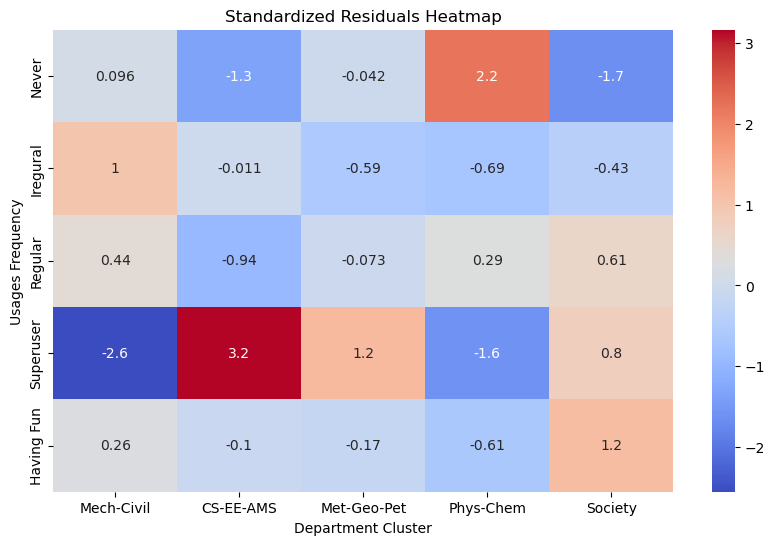

In [146]:
categories1 = ["Mech-Civil", "CS-EE-AMS", "Met-Geo-Pet", "Phys-Chem", "Society"]
categories2 = ["Never", "Iregural", "Regular", "Superuser", "Having Fun"]



heatmap_plot(categories1, categories2, res_val, "Department Cluster", "Usages Frequency")

In [147]:
# Hypothesis 2: The frequency of GenAI usage is higher for graduate students compared to undergraduate students.


In [148]:
deg = df['What degree are you enrolled in?']
freq = df['LLM-powered chatbots (e.g. ChatGPT Gemini Claude Llama etc.)']

In [149]:
contingency_table = create_con_table(freq, deg)
print(contingency_table)

What degree are you enrolled in?                      1   2   3
LLM-powered chatbots (e.g. ChatGPT Gemini Claud...             
1                                                   118  19  17
2                                                   211  28  24
3                                                   211  32  35
4                                                    59  20  31
5                                                    48   7   2


In [150]:
# Step 2: Merge the "MS" and "PhD" columns
contingency_table[2] = contingency_table[2] + contingency_table[3]

# Step 3: Select only the necessary columns (e.g., "Undergraduate" and "Graduate")
contingency_table = contingency_table[[1, 2]]

# Step 4: Remove unnecessary rows (if needed, filter rows based on criteria)
# Example: Remove rows with a frequency of "Never"
contingency_table = contingency_table.drop(index=['Never'], errors='ignore')
print(contingency_table)

What degree are you enrolled in?                      1   2
LLM-powered chatbots (e.g. ChatGPT Gemini Claud...         
1                                                   118  36
2                                                   211  52
3                                                   211  67
4                                                    59  51
5                                                    48   9


In [151]:
observed, expected = chi_square_test(contingency_table)

Chi-Square Statistic: 33.5755
P-Value: 9.105402834978417e-07
Degrees of Freedom: 4
Expected Frequencies:
[[115.58932715  38.41067285]
 [197.4025522   65.5974478 ]
 [208.6612529   69.3387471 ]
 [ 82.5638051   27.4361949 ]
 [ 42.78306265  14.21693735]]
There is a significant relationship


In [152]:
standardized_residuals = residuals_cal(observed, expected)

Standardized Residuals:
[[ 0.22422261 -0.38896661]
 [ 0.96778975 -1.67885786]
 [ 0.16190578 -0.28086348]
 [-2.59328693  4.49866322]
 [ 0.79758997 -1.38360651]]

Significant Cells (Residuals > 2 or < -2):
[[False False]
 [False False]
 [False False]
 [ True  True]
 [False False]]


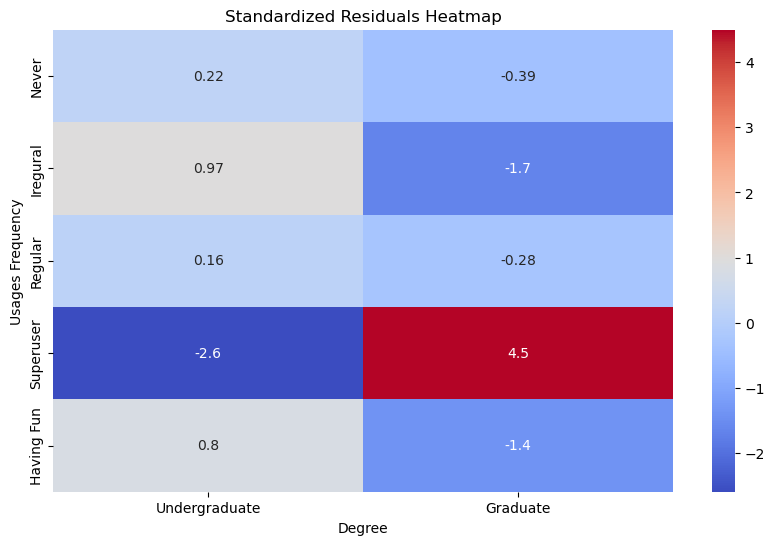

In [153]:
categories2 = ["Never", "Iregural", "Regular", "Superuser", "Having Fun"]
categories1 = ["Undergraduate", "Graduate"]

heatmap_plot(categories1, categories2, standardized_residuals, "Degree", "Usages Frequency")

In [154]:
# Hypothesis 4: Students who pay for access to LLM-powered chatbots tend to use generative AI (GenAI) tools more frequently.


In [155]:
contingency_table = create_con_table(freq, paid)
print(contingency_table)

Have you ever paid to use an advanced or pro LLM-powered chatbot (e.g. ChatGPT-4.0 Gemini Advanced Claude Pro Copilot Pro etc.)?  1.0  \
LLM-powered chatbots (e.g. ChatGPT Gemini Claud...                                                                                      
1                                                                                                                                  13   
2                                                                                                                                  38   
3                                                                                                                                  50   
4                                                                                                                                  12   
5                                                                                                                                   8   

Have you ever paid to use an advanced or

In [156]:
observed, expected = chi_square_test(contingency_table)

Chi-Square Statistic: 38.3752
P-Value: 6.4168957465811145e-06
Degrees of Freedom: 8
Expected Frequencies:
[[11.23571429  0.83571429  0.92857143]
 [33.70714286  2.50714286  2.78571429]
 [49.26428571  3.66428571  4.07142857]
 [19.87857143  1.47857143  1.64285714]
 [ 6.91428571  0.51428571  0.57142857]]
There is a significant relationship


In [157]:
standardized_residuals = residuals_cal(observed, expected)

Standardized Residuals:
[[ 0.52634266 -0.9141741  -0.96362411]
 [ 0.73941025 -0.95184203 -1.66904592]
 [ 0.10481974  0.69778062 -1.02658887]
 [-1.76707463  1.25121059  4.95977609]
 [ 0.41289716 -0.71713717 -0.75592895]]

Significant Cells (Residuals > 2 or < -2):
[[False False False]
 [False False False]
 [False False False]
 [False False  True]
 [False False False]]


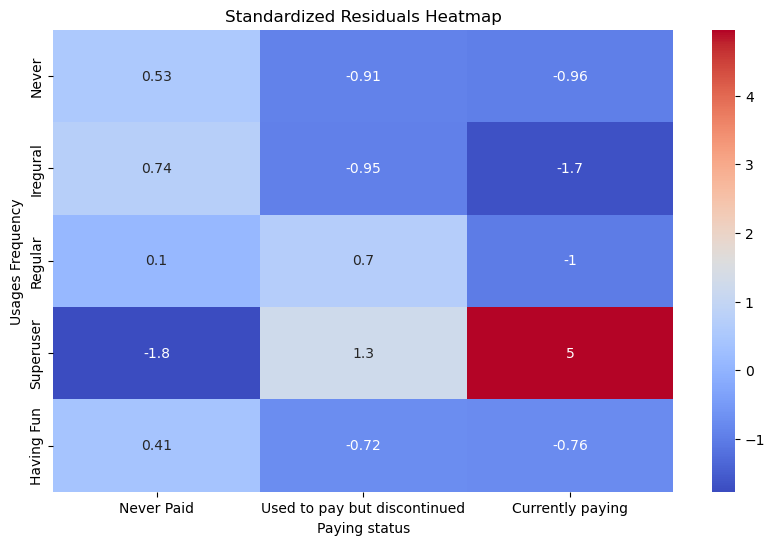

In [158]:
categories2 = ["Never", "Iregural", "Regular", "Superuser", "Having Fun"]
categories1 = ["Never Paid", "Used to pay but discontinued", "Currently paying"]

heatmap_plot(categories1, categories2, standardized_residuals, "Paying status", "Usages Frequency")

In [159]:
file_path = '/Users/jesanahammed/Desktop/dataset/combined.csv'
df_com = pd.read_csv(file_path, encoding='latin1')
df_com.columns = df_com.columns.str.replace(r'[^\x00-\x7F]+', '', regex=True)  # Remove non-ASCII characters
df_com.columns = df_com.columns.str.strip()  # Strip any leading/trailing spaces


In [160]:
print(len(df_com['Response ID']))

664


In [161]:
# SES vs P(doom)

In [162]:
ses = df_com['socioeconomic_status']
p_doom = df_com['impact_p_doom_reg']

nan_count_ses = df_com['socioeconomic_status'].isna().sum()
nan_count_p_doom = df_com['impact_p_doom_reg'].isna().sum()

print(nan_count_ses)
print(nan_count_p_doom)

print(len(df_com['Response ID']))

df_com_cleaned = df_com.dropna(subset=['socioeconomic_status'])

ses_cleaned = df_com_cleaned['socioeconomic_status'].reset_index(drop=True)
p_doom = df_com_cleaned['impact_p_doom_reg'].reset_index(drop=True)


nan_count_ses = df_com_cleaned['socioeconomic_status'].isna().sum()
nan_count_p_doom = df_com_cleaned['impact_p_doom_reg'].isna().sum()

print(nan_count_ses)
print(nan_count_p_doom)

print(len(df_com_cleaned['Response ID']))

7
0
664
0
0
657


Shapiro-Wilk Test: Statistic=0.9295487403869629, P-value=5.1191104529248584e-17
 Group: Data is NOT normally distributed.



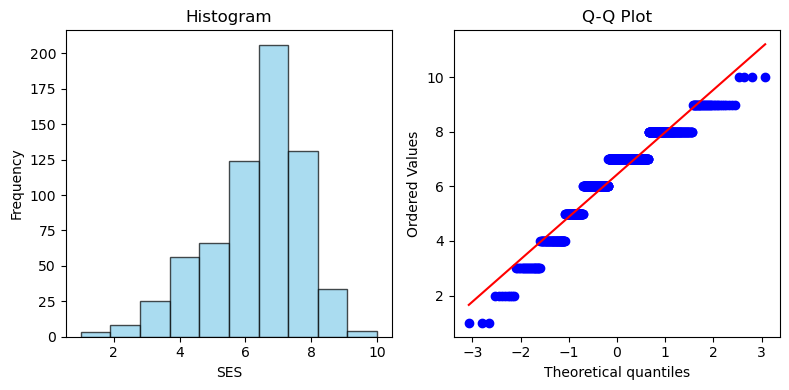

In [163]:
normality_test(ses_cleaned)

In [164]:
agostino_pearson_test(ses_cleaned)

D'Agostino and Pearson's Test: Statistic=47.9694617309421, P-value=3.833219909600439e-11
 Group: Data is NOT normally distributed.



In [165]:
ses_low_p_doom, ses_high_p_doom = create_group(ses_cleaned, p_doom)

print(len(ses_low_p_doom))
print(len(ses_high_p_doom))


286
371


In [166]:
kruskal_wallis_test(ses_low_p_doom, ses_high_p_doom)

Kruskal-Wallis Test: Statistic=6.605633669038893, P-value=0.010165662119390444
Reject the null hypothesis: There is a significant difference


In [167]:
# Combine data into a format suitable for Dunn's test
ses_data = ses_low_p_doom + ses_high_p_doom  # Combine both low and high SES data
group_labels = ['ses_low_p_doom'] * len(ses_low_p_doom) + ['ses_high_p_doom'] * len(ses_high_p_doom)  # Create corresponding group labels

# Create a DataFrame
df_new = pd.DataFrame({
    'SES': ses_data,  # SES values
    'Group': group_labels  # Corresponding groups
})

In [169]:
import scikit_posthocs as sp

In [170]:
# Perform Dunn's Post-Hoc Test using scikit-posthocs
posthoc_result = sp.posthoc_dunn(df_new, val_col='SES', group_col='Group', p_adjust='bonferroni')

# Display the result
print(posthoc_result)

                 ses_high_p_doom  ses_low_p_doom
ses_high_p_doom         1.000000        0.010166
ses_low_p_doom          0.010166        1.000000


In [171]:
# 0.010166: This is the p-value for comparing ses_high_p_doom with ses_low_p_doom in terms of SES.
# The p-value of 0.010166 is less than 0.05, indicating that there is a statistically significant difference between 
# the SES of the two groups (those who gave low and high ratings on p(doom)).
# Thus, we can conclude that people with low SES tend to give a different (likely lower or higher) rating on P(doom) 
# than people with high SES.


In [172]:
# Calculate mean or median SES for both groups
mean_ses_low_p_doom = np.mean(ses_low_p_doom)
mean_ses_high_p_doom = np.mean(ses_high_p_doom)

median_ses_low_p_doom = np.median(ses_low_p_doom)
median_ses_high_p_doom = np.median(ses_high_p_doom)

print(f"Mean SES for low P(doom) rating group: {mean_ses_low_p_doom}")
print(f"Mean SES for high P(doom) rating group: {mean_ses_high_p_doom}")

print(f"Median SES for low P(doom) rating group: {median_ses_low_p_doom}")
print(f"Median SES for high P(doom) rating group: {median_ses_high_p_doom}")

Mean SES for low P(doom) rating group: 6.629370629370629
Mean SES for high P(doom) rating group: 6.285714285714286
Median SES for low P(doom) rating group: 7.0
Median SES for high P(doom) rating group: 7.0


In [173]:
import statsmodels.api as sm

In [174]:
# Create the dependent (y) and independent (X) variables
X = sm.add_constant(df_com_cleaned['socioeconomic_status'])  # adding intercept
y = df_com_cleaned['impact_p_doom_reg'].apply(lambda x: 1 if x > 40 else 0)  # binary outcome


In [175]:
print(X.shape)
print(y.shape)

(657, 2)
(657,)


In [176]:
# Fit the logistic regression model
model = sm.Logit(y, X)
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.679051
         Iterations 4


In [177]:
# Get the summary
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      impact_p_doom_reg   No. Observations:                  657
Model:                          Logit   Df Residuals:                      655
Method:                           MLE   Df Model:                            1
Date:                Fri, 24 Jan 2025   Pseudo R-squ.:                0.008330
Time:                        10:44:14   Log-Likelihood:                -446.14
converged:                       True   LL-Null:                       -449.88
Covariance Type:            nonrobust   LLR p-value:                  0.006187
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1413      0.337      3.388      0.001       0.481       1.801
socioeconomic_status    -0.1363      0.050     -2.703      0.007      -0.235      -0.037


In [178]:
# Years at mines vs P(doom)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [182]:
years_at_mines = df['How many years have you been at Mines?']
p_doom = df['Impact of P(doom)']

nan_count_ses = df['How many years have you been at Mines?'].isna().sum()
nan_count_p_doom = df['Impact of P(doom)'].isna().sum()

print(nan_count_ses)
print(nan_count_p_doom)

print(len(df['Response ID']))


df_genai_cleaned = df.dropna(subset=['Impact of P(doom)'])

print(len(df_genai_cleaned['Response ID']))

years_at_mines_cleaned = df_genai_cleaned['How many years have you been at Mines?'].reset_index(drop=True)
p_doom_cleaned = df_genai_cleaned['Impact of P(doom)'].reset_index(drop=True)

print(len(years_at_mines_cleaned))


0
198
862
664
664


Shapiro-Wilk Test: Statistic=0.8435588479042053, P-value=4.758796508212833e-25
 Group: Data is NOT normally distributed.



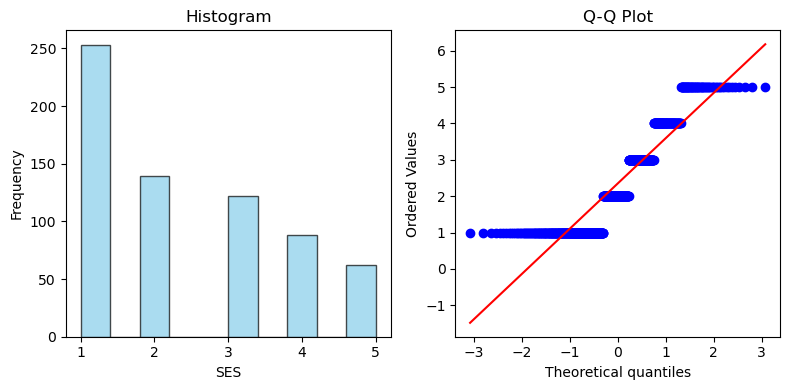

In [183]:
normality_test(years_at_mines_cleaned)

In [184]:
agostino_pearson_test(years_at_mines_cleaned)

D'Agostino and Pearson's Test: Statistic=119.85609898976303, P-value=9.409765339737647e-27
 Group: Data is NOT normally distributed.



In [185]:
years_low_p_doom, years_high_p_doom = create_group(years_at_mines_cleaned, p_doom_cleaned)

print(len(years_low_p_doom))
print(len(years_high_p_doom))

290
374


In [186]:
kruskal_wallis_test(years_low_p_doom, years_high_p_doom)

Kruskal-Wallis Test: Statistic=0.17910048481490695, P-value=0.6721474119216675
Fail to reject the null hypothesis: No significant difference.


In [187]:
# Department cluster vs P(doom)

In [188]:
print(len(df_com['Response ID']))

664


In [189]:
p_doom = df_com['impact_p_doom_reg']
print(p_doom.isna().sum())

mech_civil = df_com['dept_Mech_Civil']
cs_ee_asm = df_com['dept_CS_EE_AMS']
met_geo_pet = df_com['dept_Met_Geo_Pet']
phys_chem = df_com['dept_Phys_Chem']
society = df_com['dept_Society']

0


In [190]:
p_doom_mech_civil = []
p_doom_cs_ee_asm = []
p_doom_met_geo_pet = []
p_doom_phys_chem = []
p_doom_society = []


for i in range(len(p_doom)):
    if mech_civil[i] == 1:
        p_doom_mech_civil.append(p_doom[i])
    elif cs_ee_asm[i] == 1:
        p_doom_cs_ee_asm.append(p_doom[i])
    elif met_geo_pet[i] == 1:
        p_doom_met_geo_pet.append(p_doom[i])
    elif phys_chem[i] == 1:
        p_doom_phys_chem.append(p_doom[i])
    elif society[i] == 1:
        p_doom_society.append(p_doom[i])
        

In [191]:
print(len(p_doom_mech_civil))
print(len(p_doom_cs_ee_asm))
print(len(p_doom_met_geo_pet))
print(len(p_doom_phys_chem))
print(len(p_doom_society))

243
184
86
128
23


In [196]:
from scipy.stats import kruskal
groups = [p_doom_mech_civil, p_doom_cs_ee_asm, p_doom_met_geo_pet, p_doom_phys_chem, p_doom_society]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis Test: Statistic={stat}, P-value={p}")
    
# Interpretation
if p < 0.05:
    print("There is a significant difference in the P(doom) values across groups.")
else:
    print("There is no significant difference in the P(doom) values across groups.")
        

Kruskal-Wallis Test: Statistic=1.402989482604272, P-value=0.84367526378548
There is no significant difference in the P(doom) values across groups.
